Waste Management Analysis of Irish Counties


### Dataset Description

**Waste Generation**

The Waste Generation Dataset has 19,656 records providing the quarterly waste generation per county. The dataset consists of five columns: Quarter, the time period (e.g., "Q1 2020"); County, the area where the waste was generated; Waste Type, the type of waste (e.g., organic or recyclable); Waste Category, the general category of waste (e.g., household, industrial); Waste Amount (tonnes), the amount of waste generated. The dataset is comprehensive, except for columns Quarter (18,657 non-null), County (18,985 non-null), Waste Amount (tonnes) (18,632 non-null) which have missing values Also, even the numerical ones are stored in objects hence the data type conversion is needed in pre-processing phase to carry out the subsequent analysis like Waste Amount (tonnes).

**Waste Treatment**

Description of the Dataset The Waste Treatment Dataset ( Waste_ Treatment_ Dataset.csv) contains about 45,864 records of waste treatment in various counties and quarters. It contains seven columns: Quarter, denoting the time period; County, identifying the treatment location; Waste Type and Waste Category, describing specific and general classifications of the waste; Treatment Method, indicating the method (e.g., recycling, incineration) used to treat the waste; Waste Amount (tonnes), specifying the amount of waste treated; and Price of Treatment (€ per tonne), specifying the price to treat for one tonne of waste. As we can see, it also has missing data with critical columns such as Quarter (43,521 non-null), County (43,573 non-null), and Waste Amount (tonnes) (43,634 non-null). On the other hand, the Price of Treatment (€ per tonne) column contains no missing entries. Just like the Waste Generation Dataset, this dataset also has all columns stored as objects; thus, we need to convert the Waste Amount (tonnes) and Price of Treatment (€ per tonne) columns into numerical fields so that we can perform a proper analysis.



## **Basic libraries for data analysis and visualization are imported by this code. Seaborn and matplotlib, pandas and numpy are used to visualize data processing. re facilitates text processing, while warnings.filterwarnings('ignore') cleans up the analysis environment by suppressing unnecessary alerts.**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mat
import seaborn as sns
import pandas as pd
import numpy as np
import re

import warnings  #to ignore warnings
warnings.filterwarnings('ignore')

##**Loads the quarterly_waste_generation.csv and quarterly_waste_treatment.csv files into data frames df1 and df2. The first five rows of both data frames are then displayed using head(5). This is a fundamental step to examine the data structure, column names and sample data. Therefore, problems such as inconsistent or missing values in the data can be identified in advance.**

In [ ]:
df1 = pd.read_csv("quarterly_waste_generation.csv")  #reading the datasets

In [ ]:
df2 = pd.read_csv("quarterly_waste_treatment.csv")

In [ ]:
df1.head(5)

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
0,2004 Q4,Co. Antrim,Hazardous,Chemical_Waste,"14,019.80"
1,01-01-2004,Antrim,Hazardous,Waste Electronic (E-Waste),"16,585.47"
2,01/01/2004,Antrim,Hazardous,Industrial Hazardous Waste,"20,131.46"
3,Q1 2004,county Antrim,Hazardous,Waste Medical,NaN
4,2004Q1,Antrim co.,Non-Hazardous,Agricultural_Waste,"10,779.94"


In [ ]:
df2.head(5)

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
0,2004Q1,Antrim,Hazardous,Chemical Waste,disposal - incineration,9813.86 tonnes,348.259420051236 €/tonne
1,Q1 2004,county Antrim,Hazardous,Chemical Waste,disposal - other,4205.94,255.40 € tonne
2,2004 Q1,Antrim,Hazardous,Waste (E-Waste) Electronic,RECOVERY - RECYCLING,14926.92,69 euros/t
3,2004 Q4,Antrim,Hazardous,Electronic Waste (E-Waste),disposal - other,1658.55,152.09 € tonne
4,NaN,Antrim,Hazardous,INDUSTRIAL HAZARDOUS WASTE,Disposal - incineration,"12,078",59.211277 euros per tonne


##**These codes contains basic information about the data structure on the df1 and df2 data frames. The shape method is used to better understand the data size by showing the number of rows and columns of each data frame. To examine samples from the last part of the data set, the tail(5) method displays the last five rows of both data frames. This is especially useful for finding issues such as missing data or data integrity.**


In [ ]:
df1.shape


In [ ]:
df2.shape

(45864, 7)

In [ ]:
df1.tail(5)


,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
19651,2024-10-01,Wicklow,Non-Hazardous,AGRICULTURAL WASTE,15959.17
19652,01-10-2024,Wicklow,Non-Hazardous,Demolition Construction Waste and,9311.680000
19653,2024Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,"14,704.54"
19654,2024-10-01,Wicklow,Non-Hazardous,M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.,19583.37
19655,2024 Q1,NaN,Non-Hazardous,ORGANIC WASTE,8601.830000


In [ ]:
df2.tail(5)

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
45859,2024Q4,Wicklow Co.,Non-Hazardous,Municipal Solid Waste,D.i.s.p.o.s.a.l. - l.a.n.d.f.i.l.l.,"9,791",66.16108622368807 € tonne
45860,01/10/2024,Wicklow Co.,Non-Hazardous,municipal solid waste,Recovery_-_recycling,5875.01,54 euros per tonne
45861,"October 01, 2024",Wicklow,Non-Hazardous,M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.,recovery energy - Recovery,3916.67,66.666333 € tonne
45862,"October 01, 2024",Wicklow,Non-Hazardous,Organic Waste,Recovery - composting,6021.28,48.64 € per tonne
45863,01 October 2024,Wicklow,Non-Hazardous,organic waste,Recovery_-_energy_recovery,2580.55,72.217191 euros per tonne


## • Examining and processing the data to obtain the desired format

##**These codes shows the dimensions and column names of the df1 and df2 data frames. In addition, it examines the general structures of both data sets through the info() method. This method allows to understand the data types of the columns, the number of missing values and the total amount of entries. dtypes details the data types in the columns. This information is a great start to learn more about the structure of the data set and plan the necessary steps for cleaning and transforming the data.**

In [ ]:
print("Shape of the waste generation dataset:",df1.shape)
print("Shape of the waste treatment dataset:",df2.shape)

Shape of the waste generation dataset: (19656, 5)
Shape of the waste treatment dataset: (45864, 7)


In [ ]:
print("Columns in the waste generation dataset:",df1.columns)
print("Columns in the waste treatment dataset:",df2.columns)

Columns in the waste generation dataset: Index(['Quarter', 'County', 'Waste Type', 'Waste Category',
       'Waste Amount (tonnes)'],
      dtype='object')
Columns in the waste treatment dataset: Index(['Quarter', 'County', 'Waste Type', 'Waste Category', 'Treatment Method',
       'Waste Amount (tonnes)', 'Price of Treatment (€ per tonne)'],
      dtype='object')


In [ ]:

print(df1.info())
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19656 entries, 0 to 19655
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Quarter                18657 non-null  object
 1   County                 18985 non-null  object
 2   Waste Type             18640 non-null  object
 3   Waste Category         19217 non-null  object
 4   Waste Amount (tonnes)  18632 non-null  object
dtypes: object(5)
memory usage: 767.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45864 entries, 0 to 45863
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Quarter                           43521 non-null  object
 1   County                            43573 non-null  object
 2   Waste Type                        43568 non-null  object
 3   Waste Category                    44757 non-null  object
 4   Tre

In [ ]:
print("Datatypes in the waste generation dataset:",df1.dtypes)
print("Datatypes in the waste treatment dataset:",df2.dtypes)

Datatypes in the waste generation dataset: Quarter                  object
County                   object
Waste Type               object
Waste Category           object
Waste Amount (tonnes)    object
dtype: object
Datatypes in the waste treatment dataset: Quarter                             object
County                              object
Waste Type                          object
Waste Category                      object
Treatment Method                    object
Waste Amount (tonnes)               object
Price of Treatment (€ per tonne)    object
dtype: object


##**These codes shows the unique element counts (nunique()), statistical summaries (describe()) and first few rows (head()) of the df1 and df2 data frames. nunique() provides more information about the diversity of the data and the structure of the categorical columns. describe() provides basic statistics (mean, minimum, maximum, etc.) for numeric columns. Finally, head() examines the data structure by showing the first rows of the data set and recognises potential problems early. These steps provide a comprehensive start for data analysis.**

In [ ]:
print("Number of unique elements in the entire waste generation dataset:\n",df1.nunique())

Number of unique elements in the entire waste generation dataset:
 Quarter                    672
County                     242
Waste Type                   2
Waste Category             114
Waste Amount (tonnes)    18084
dtype: int64


In [ ]:
print("Number of unique elements in the entire waste treatment dataset:\n",df2.nunique())

Number of unique elements in the entire waste treatment dataset:
 Quarter                               672
County                                234
Waste Type                              2
Waste Category                        114
Treatment Method                       94
Waste Amount (tonnes)               39436
Price of Treatment (€ per tonne)    33572
dtype: int64


In [ ]:
df1.describe()

,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
count,18657,18985,18640,19217,18632
unique,672,242,2,114,18084
top,2013Q3,Galway,Non-Hazardous,Medical Waste,15475
freq,106,531,10355,415,4


In [ ]:
df2.describe()

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
count,43521,43573,43568,44757,44750,43634,45864
unique,672,234,2,114,94,39436,33572
top,2007Q3,Wicklow,Non-Hazardous,Agricultural Waste,Disposal - other,"4,156",59 € tonne
freq,242,1194,26970,1241,1531,6,70


In [ ]:
df1.head()



,Quarter,County,Waste Type,Waste Category,Waste Amount (tonnes)
0,2004 Q4,Co. Antrim,Hazardous,Chemical_Waste,"14,019.80"
1,01-01-2004,Antrim,Hazardous,Waste Electronic (E-Waste),"16,585.47"
2,01/01/2004,Antrim,Hazardous,Industrial Hazardous Waste,"20,131.46"
3,Q1 2004,county Antrim,Hazardous,Waste Medical,NaN
4,2004Q1,Antrim co.,Non-Hazardous,Agricultural_Waste,"10,779.94"


In [ ]:
df2.head()

,Quarter,County,Waste Type,Waste Category,Treatment Method,Waste Amount (tonnes),Price of Treatment (€ per tonne)
0,2004Q1,Antrim,Hazardous,Chemical Waste,disposal - incineration,9813.86 tonnes,348.259420051236 €/tonne
1,Q1 2004,county Antrim,Hazardous,Chemical Waste,disposal - other,4205.94,255.40 € tonne
2,2004 Q1,Antrim,Hazardous,Waste (E-Waste) Electronic,RECOVERY - RECYCLING,14926.92,69 euros/t
3,2004 Q4,Antrim,Hazardous,Electronic Waste (E-Waste),disposal - other,1658.55,152.09 € tonne
4,NaN,Antrim,Hazardous,INDUSTRIAL HAZARDOUS WASTE,Disposal - incineration,"12,078",59.211277 euros per tonne


##**It makes the column names in the frames df1 and df2 data. str.lower() converts all letters to lower case, while str.replace(' ', '_') replaces spaces in column names with underscores. Standardises the column names, however, making it easier to access the columns and reducing the risk of possible errors when writing code.**

In [ ]:
df1.columns = df1.columns.str.replace(' ', '_').str.lower()
df2.columns = df2.columns.str.replace(' ', '_').str.lower()

# Standardizing the quarter column



##**The quarter column in the df1 data frame is changed to the ‘YYYY QX’ format. The quarter to provide future consistency, invalid values remain untouched. However, this is purely to keep things simple and for analyses.**

In [ ]:
# Inline approach to convert dates to quarters while ignoring existing quarters
df1['quarter'] = df1['quarter'].apply(
    lambda x: x if re.match(r'\d{4}\s?Q\d', str(x))  # Check if already in quarter format
    else f"{pd.to_datetime(x, errors='coerce').year} Q{((pd.to_datetime(x, errors='coerce').month - 1) // 3 + 1)}"
    if pd.notnull(pd.to_datetime(x, errors='coerce'))  # Check if the date conversion is valid
    else x  # Return original if conversion fails
)

##**These codes format quarter column in df1 data frame properly That is, if ‘Q1’, ‘Q2’, ‘Q3’ and ‘Q4’ do not have spaces firstly, it adds spaces before these questions. This process normalizes the quarter information to the ‘YYYY QX’ shape to make the column data more uniform and readable. This standardisation is essential to reduce errors in processing time series data and in data analysis.**

In [ ]:
# df['Quarter'] = df['Quarter'].str.replace("Q1", " Q1").str.replace("Q2", " Q2").str.replace("Q3", " Q3").str.replace("Q4", " Q4")

df1['quarter'] = df1['quarter'].str.replace(r'(?<!\s)(Q1)', ' Q1', regex=True) \
                             .str.replace(r'(?<!\s)(Q2)', ' Q2', regex=True) \
                             .str.replace(r'(?<!\s)(Q3)', ' Q3', regex=True) \
                             .str.replace(r'(?<!\s)(Q4)', ' Q4', regex=True) #\
                             #.str.replace(r'(?<!\s)(Q4)', ' 2', regex=True)


#data['Quarter'] = data['Quarter'].str.replace(r'',' ')

#df['Quarter'] = df['Quarter'].str.replace(' ',r'')

##**These codes assumes that half column in the df1 data frame is a format of time string in order. Q1-4 Y Of Format to YYYY QX converter: First it converts the quarter information in the‘QX YYYYY’format to‘YYYYY QX’format The leading spaces are trimmed with `str. lstrip(). This process ensures the uniformity of the quarter data, resulting in fewer mistakes in data processing and time series.**

In [ ]:
#df['Quarter'] = df['Quarter'].str.lstrip()  #removing space

In [ ]:
#df['Quarter'] = df['Quarter'].str.replace(r'(\d{4})\s?Q(\d)', r'Q\2 \1', regex=True)

In [ ]:
df1['quarter'] = df1['quarter'].str.replace(r'(Q\d)\s(\d{4})', r'\2 \1', regex=True)
df1['quarter'] = df1['quarter'].str.lstrip() #removes space in the beginning of the word

In [ ]:
df1

,quarter,county,waste_type,waste_category,waste_amount_(tonnes)
0,2004 Q4,Co. Antrim,Hazardous,Chemical_Waste,"14,019.80"
1,2004 Q1,Antrim,Hazardous,Waste Electronic (E-Waste),"16,585.47"
2,2004 Q1,Antrim,Hazardous,Industrial Hazardous Waste,"20,131.46"
3,2004 Q1,county Antrim,Hazardous,Waste Medical,NaN
4,2004 Q1,Antrim co.,Non-Hazardous,Agricultural_Waste,"10,779.94"
...,...,...,...,...,...
19651,2024 Q4,Wicklow,Non-Hazardous,AGRICULTURAL WASTE,15959.17
19652,2024 Q1,Wicklow,Non-Hazardous,Demolition Construction Waste and,9311.680000
19653,2024 Q4,Wicklow,Non-Hazardous,industrial non-hazardous waste,"14,704.54"
19654,2024 Q4,Wicklow,Non-Hazardous,M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.,19583.37


##**These codes format df2’s quarter column into the ‘YYYY QX’ format and stores it as a single column. Step 1: Preserve values in the current format and quarter calculation converts back in time that would have been valid Spaces are inserted before the quarter expressions if needed. Finally the expressions ‘QX YYYYY’ will be converted to format ‘YYYYY QX’ and unnecessary spaces will be removed from beginning. It preserves the data consistency across its four columns and allows for the performance of various time series analyses.**

In [ ]:
# Inline approach to convert dates to quarters while ignoring existing quarters
df2['quarter'] = df2['quarter'].apply(
    lambda x: x if re.match(r'\d{4}\s?Q\d', str(x))  # Check if already in quarter format
    else f"{pd.to_datetime(x, errors='coerce').year} Q{((pd.to_datetime(x, errors='coerce').month - 1) // 3 + 1)}"
    if pd.notnull(pd.to_datetime(x, errors='coerce'))  # Check if the date conversion is valid
    else x  # Return original if conversion fails
)


df2['quarter'] = df2['quarter'].str.replace(r'(?<!\s)(Q1)', ' Q1', regex=True) \
                             .str.replace(r'(?<!\s)(Q2)', ' Q2', regex=True) \
                             .str.replace(r'(?<!\s)(Q3)', ' Q3', regex=True) \
                             .str.replace(r'(?<!\s)(Q4)', ' Q4', regex=True)


df2['quarter'] = df2['quarter'].str.replace(r'(Q\d)\s(\d{4})', r'\2 \1', regex=True)
df2['quarter'] = df2['quarter'].str.lstrip() #removes space in the beginning of the word


In [ ]:
df2

,quarter,county,waste_type,waste_category,treatment_method,waste_amount_(tonnes),price_of_treatment_(€_per_tonne)
0,2004 Q1,Antrim,Hazardous,Chemical Waste,disposal - incineration,9813.86 tonnes,348.259420051236 €/tonne
1,2004 Q1,county Antrim,Hazardous,Chemical Waste,disposal - other,4205.94,255.40 € tonne
2,2004 Q1,Antrim,Hazardous,Waste (E-Waste) Electronic,RECOVERY - RECYCLING,14926.92,69 euros/t
3,2004 Q4,Antrim,Hazardous,Electronic Waste (E-Waste),disposal - other,1658.55,152.09 € tonne
4,NaN,Antrim,Hazardous,INDUSTRIAL HAZARDOUS WASTE,Disposal - incineration,"12,078",59.211277 euros per tonne
...,...,...,...,...,...,...,...
45859,2024 Q4,Wicklow Co.,Non-Hazardous,Municipal Solid Waste,D.i.s.p.o.s.a.l. - l.a.n.d.f.i.l.l.,"9,791",66.16108622368807 € tonne
45860,2024 Q1,Wicklow Co.,Non-Hazardous,municipal solid waste,Recovery_-_recycling,5875.01,54 euros per tonne
45861,2024 Q4,Wicklow,Non-Hazardous,M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.,recovery energy - Recovery,3916.67,66.666333 € tonne
45862,2024 Q4,Wicklow,Non-Hazardous,Organic Waste,Recovery - composting,6021.28,48.64 € per tonne


##**These codes examines the standardised state of the four columns in data frames df1 and df2. First, the number of occurrences of each quadrant in df1 is found by group and by number. Then the unique() method is used to obtain the unique quarter values in both data sets. These special values are printed on the screen to check the accuracy of the standardisation process. As a result, it guarantees that the data is in the correct format to guarantee the consistency of the quarter column and to make the analysis correct.**

In [ ]:
Date = df1.groupby(by='quarter')['quarter'].count()
Date.head(9)

quarter
2004 Q1    344
2004 Q2    179
2004 Q3    184
2004 Q4    180
2005 Q1    355
2005 Q2    163
2005 Q3    193
2005 Q4    176
2006 Q1    363
Name: quarter, dtype: int64

In [ ]:
df1['quarter'].unique()

array(['2004 Q4', '2004 Q1', nan, '2004 Q2', '2004 Q3', '2005 Q1',
       '2005 Q4', '2005 Q2', '2005 Q3', '2006 Q1', '2006 Q4', '2006 Q2',
       '2006 Q3', '2007 Q1', '2007 Q3', '2007 Q4', '2007 Q2', '2008 Q1',
       '2008 Q2', '2008 Q4', '2008 Q3', '2009 Q4', '2009 Q1', '2009 Q2',
       '2009 Q3', '2010 Q1', '2010 Q3', '2010 Q4', '2010 Q2', '2011 Q1',
       '2011 Q3', '2011 Q4', '2011 Q2', '2012 Q1', '2012 Q2', '2012 Q4',
       '2012 Q3', '2013 Q2', '2013 Q1', '2013 Q3', '2013 Q4', '2014 Q4',
       '2014 Q1', '2014 Q3', '2014 Q2', '2015 Q1', '2015 Q3', '2015 Q2',
       '2015 Q4', '2016 Q1', '2016 Q3', '2016 Q4', '2016 Q2', '2017 Q4',
       '2017 Q1', '2017 Q2', '2017 Q3', '2018 Q1', '2018 Q4', '2018 Q3',
       '2018 Q2', '2019 Q2', '2019 Q1', '2019 Q4', '2019 Q3', '2020 Q1',
       '2020 Q4', '2020 Q3', '2020 Q2', '2021 Q3', '2021 Q1', '2021 Q2',
       '2021 Q4', '2022 Q1', '2022 Q4', '2022 Q3', '2022 Q2', '2023 Q2',
       '2023 Q1', '2023 Q3', '2023 Q4', '2024 Q1', '2024 

In [ ]:
df2['quarter'].unique()

array(['2004 Q1', '2004 Q4', nan, '2004 Q2', '2004 Q3', '2005 Q1',
       '2005 Q4', '2005 Q2', '2005 Q3', '2006 Q1', '2006 Q4', '2006 Q3',
       '2006 Q2', '2007 Q1', '2007 Q2', '2007 Q3', '2007 Q4', '2008 Q1',
       '2008 Q2', '2008 Q4', '2008 Q3', '2009 Q1', '2009 Q3', '2009 Q2',
       '2009 Q4', '2010 Q1', '2010 Q3', '2010 Q4', '2010 Q2', '2011 Q1',
       '2011 Q2', '2011 Q4', '2011 Q3', '2012 Q1', '2012 Q2', '2012 Q3',
       '2012 Q4', '2013 Q1', '2013 Q2', '2013 Q3', '2013 Q4', '2014 Q1',
       '2014 Q2', '2014 Q4', '2014 Q3', '2015 Q1', '2015 Q4', '2015 Q3',
       '2015 Q2', '2016 Q1', '2016 Q3', '2016 Q2', '2016 Q4', '2017 Q1',
       '2017 Q4', '2017 Q2', '2017 Q3', '2018 Q1', '2018 Q4', '2018 Q3',
       '2018 Q2', '2019 Q2', '2019 Q1', '2019 Q4', '2019 Q3', '2020 Q1',
       '2020 Q2', '2020 Q3', '2020 Q4', '2021 Q1', '2021 Q2', '2021 Q3',
       '2021 Q4', '2022 Q1', '2022 Q2', '2022 Q4', '2022 Q3', '2023 Q1',
       '2023 Q2', '2023 Q3', '2023 Q4', '2024 Q1', '2024 

In [ ]:
print("After standardization, distinct quarters appear in the generation dataset:\n", df1['quarter'].unique())

After standardization, distinct quarters appear in the generation dataset:
 ['2004 Q4' '2004 Q1' nan '2004 Q2' '2004 Q3' '2005 Q1' '2005 Q4' '2005 Q2'
 '2005 Q3' '2006 Q1' '2006 Q4' '2006 Q2' '2006 Q3' '2007 Q1' '2007 Q3'
 '2007 Q4' '2007 Q2' '2008 Q1' '2008 Q2' '2008 Q4' '2008 Q3' '2009 Q4'
 '2009 Q1' '2009 Q2' '2009 Q3' '2010 Q1' '2010 Q3' '2010 Q4' '2010 Q2'
 '2011 Q1' '2011 Q3' '2011 Q4' '2011 Q2' '2012 Q1' '2012 Q2' '2012 Q4'
 '2012 Q3' '2013 Q2' '2013 Q1' '2013 Q3' '2013 Q4' '2014 Q4' '2014 Q1'
 '2014 Q3' '2014 Q2' '2015 Q1' '2015 Q3' '2015 Q2' '2015 Q4' '2016 Q1'
 '2016 Q3' '2016 Q4' '2016 Q2' '2017 Q4' '2017 Q1' '2017 Q2' '2017 Q3'
 '2018 Q1' '2018 Q4' '2018 Q3' '2018 Q2' '2019 Q2' '2019 Q1' '2019 Q4'
 '2019 Q3' '2020 Q1' '2020 Q4' '2020 Q3' '2020 Q2' '2021 Q3' '2021 Q1'
 '2021 Q2' '2021 Q4' '2022 Q1' '2022 Q4' '2022 Q3' '2022 Q2' '2023 Q2'
 '2023 Q1' '2023 Q3' '2023 Q4' '2024 Q1' '2024 Q2' '2024 Q3' '2024 Q4']


In [ ]:

print("After standardization, distinct quarters appear in the treatment dataset:\n", df2['quarter'].unique())

After standardization, distinct quarters appear in the treatment dataset:
 ['2004 Q1' '2004 Q4' nan '2004 Q2' '2004 Q3' '2005 Q1' '2005 Q4' '2005 Q2'
 '2005 Q3' '2006 Q1' '2006 Q4' '2006 Q3' '2006 Q2' '2007 Q1' '2007 Q2'
 '2007 Q3' '2007 Q4' '2008 Q1' '2008 Q2' '2008 Q4' '2008 Q3' '2009 Q1'
 '2009 Q3' '2009 Q2' '2009 Q4' '2010 Q1' '2010 Q3' '2010 Q4' '2010 Q2'
 '2011 Q1' '2011 Q2' '2011 Q4' '2011 Q3' '2012 Q1' '2012 Q2' '2012 Q3'
 '2012 Q4' '2013 Q1' '2013 Q2' '2013 Q3' '2013 Q4' '2014 Q1' '2014 Q2'
 '2014 Q4' '2014 Q3' '2015 Q1' '2015 Q4' '2015 Q3' '2015 Q2' '2016 Q1'
 '2016 Q3' '2016 Q2' '2016 Q4' '2017 Q1' '2017 Q4' '2017 Q2' '2017 Q3'
 '2018 Q1' '2018 Q4' '2018 Q3' '2018 Q2' '2019 Q2' '2019 Q1' '2019 Q4'
 '2019 Q3' '2020 Q1' '2020 Q2' '2020 Q3' '2020 Q4' '2021 Q1' '2021 Q2'
 '2021 Q3' '2021 Q4' '2022 Q1' '2022 Q2' '2022 Q4' '2022 Q3' '2023 Q1'
 '2023 Q2' '2023 Q3' '2023 Q4' '2024 Q1' '2024 Q2' '2024 Q4' '2024 Q3']


# Standardizing the county column

##**This code standardises the county column in the df1 and df2 data frames. This standardisation uses the list of counties in Ireland. It recognises ‘nan’ values, corrects compatible county names and leaves non-compatible ones the same. The aim of this process is to reduce analysis errors by making county names consistent.**

In [ ]:
# List of Irish counties
irish_counties = [
    "Antrim", "Armagh", "Carlow", "Cavan", "Clare", "Cork", "Derry", "Donegal",
    "Down", "Dublin", "Fermanagh", "Galway", "Kerry", "Kildare", "Kilkenny",
    "Laois", "Leitrim", "Limerick", "Longford", "Louth", "Mayo", "Meath",
    "Monaghan", "Offaly", "Roscommon", "Sligo", "Tipperary", "Tyrone",
    "Waterford", "Westmeath", "Wexford", "Wicklow",
]

# Standardize the County column
def standardize_county(row, counties):
    # Handle variations of "nan"
    if "nan" in str(row).lower():
        return "nan"
    # Match against Irish counties
    for county in counties:
        if county.lower() in str(row).lower():
            return county
    return row  # Return original value if no match is found

# Apply the function to the County column
df1['county'] = df1['county'].apply(standardize_county, counties=irish_counties)
df2['county'] = df2['county'].apply(standardize_county, counties=irish_counties)

##**This code shows the different values in the county columns of the df1 and df2 data frames. The unique() method is used to extract the different county names of both data sets and print them to the screen. This procedure is used to determine whether the county names are correctly and consistently arranged after standardisation.**


In [ ]:
# Display the unique values in the updated 'County' column for both datasets
unique_counties_generation = df1['county'].unique()
unique_counties_treatment = df2['county'].unique()



In [ ]:

print("After standardization, distinct county names appear in the generation dataset:\n",unique_counties_generation)

After standardization, distinct county names appear in the generation dataset:
 ['Antrim' 'Carlow' 'Cavan' 'Clare' 'Cork' 'Donegal' 'Down' 'Dublin'
 'Galway' 'Kerry' 'Kildare' 'Kilkenny' 'nan' 'Laois' 'Limerick' 'Louth'
 'Mayo' 'Meath' 'Monaghan' 'Offaly' 'Roscommon' 'Sligo' 'Tipperary'
 'Waterford' 'Wexford' 'Wicklow']


In [ ]:

print("After standardization, distinct county names appear in the treatment dataset:\n",unique_counties_treatment)

After standardization, distinct county names appear in the treatment dataset:
 ['Antrim' 'Carlow' 'Cavan' 'nan' 'Clare' 'Cork' 'Donegal' 'Down' 'Dublin'
 'Galway' 'Kerry' 'Kildare' 'Kilkenny' 'Laois' 'Limerick' 'Louth' 'Mayo'
 'Meath' 'Monaghan' 'Offaly' 'Roscommon' 'Sligo' 'Tipperary' 'Waterford'
 'Wexford' 'Wicklow']


# Standardizing the waste_type column

##**This script analyses the waste_type column in the df1 and df2 data frames. First, the unique() method is used to identify the different waste types in each data set and print them to the screen. Then, using the grouping and count functions, the number of repetitions of each waste type in the data set is found.**

In [ ]:
# inspecting waste type column
unique_waste_type_generation = df1['waste_type'].unique()
unique_waste_type_treatment = df2['waste_type'].unique()

print("waste types in generation\n",unique_waste_type_generation)
print("waste types in generation\n",unique_waste_type_treatment)

waste types in generation
 ['Hazardous' 'Non-Hazardous' nan]
waste types in generation
 ['Hazardous' 'Non-Hazardous' nan]


In [ ]:
data = df2.groupby(by='waste_type')['waste_type'].count()
data

waste_type
Hazardous        16598
Non-Hazardous    26970
Name: waste_type, dtype: int64

In [ ]:
Date1 = df1.groupby(by='waste_type')['waste_type'].count()
Date1.head(150)

waste_type
Hazardous         8285
Non-Hazardous    10355
Name: waste_type, dtype: int64

**The waste_type column has only two types which is clean and no need to be standardized.**





# Standardizing the waste_category column

##**This script uses the unique() function to identify different values in the waste_category column in the df1 and df2 data frames. This procedure is used to identify the various waste categories present in each dataset.**


In [ ]:
df1['waste_category'].unique()

array(['Chemical_Waste', 'Waste Electronic (E-Waste)',
       'Industrial Hazardous Waste', 'Waste Medical',
       'Agricultural_Waste', 'CONSTRUCTION AND DEMOLITION WASTE',
       'INDUSTRIAL NON-HAZARDOUS WASTE',
       'M u n i c i p a l  S o l i d  W a s t e ', '   Organic Waste  ',
       'Chemical Waste', 'Waste Industrial Hazardous', 'MEDICAL WASTE',
       '   Agricultural Waste  ',
       'C o n s t r u c t i o n  a n d  D e m o l i t i o n  W a s t e ',
       'Waste Municipal Solid', 'Organic Waste',
       'C h e m i c a l  W a s t e ', 'Electronic_Waste_(E-Waste)',
       'I.n.d.u.s.t.r.i.a.l. H.a.z.a.r.d.o.u.s. W.a.s.t.e.',
       'medical waste', 'Agricultural Waste',
       'Construction_and_Demolition_Waste', 'NAN',
       'O r g a n i c  W a s t e ', '   Electronic Waste (E-Waste)  ',
       'Medical_Waste',
       'C.o.n.s.t.r.u.c.t.i.o.n. a.n.d. D.e.m.o.l.i.t.i.o.n. W.a.s.t.e.',
       'Municipal_Solid_Waste', 'electronic waste (e-waste)',
       'I n d u s t r i a

In [ ]:
df2['waste_category'].unique()

array(['Chemical Waste', '   Chemical Waste  ',
       'Waste (E-Waste) Electronic', 'Electronic Waste (E-Waste)',
       'INDUSTRIAL HAZARDOUS WASTE', 'Industrial_Hazardous_Waste',
       'M.e.d.i.c.a.l. W.a.s.t.e.', 'MEDICAL WASTE', 'AGRICULTURAL WASTE',
       'A.g.r.i.c.u.l.t.u.r.a.l. W.a.s.t.e.',
       'construction and demolition waste',
       'C.o.n.s.t.r.u.c.t.i.o.n. a.n.d. D.e.m.o.l.i.t.i.o.n. W.a.s.t.e.',
       'Industrial Non-Hazardous Waste',
       '   Industrial Non-Hazardous Waste  ',
       'industrial non-hazardous waste', '   Municipal Solid Waste  ',
       'Municipal Solid Waste',
       'M.u.n.i.c.i.p.a.l. S.o.l.i.d. W.a.s.t.e.', nan, 'organic waste',
       'Electronic_Waste_(E-Waste)', 'Industrial Hazardous Waste',
       '   nan  ', 'Medical Waste', 'agricultural waste',
       'Agricultural Waste', 'Construction and Demolition Waste',
       'Demolition and Construction Waste',
       'I n d u s t r i a l  N o n -H a z a r d o u s  W a s t e ',
       'I.n.d

##**This code standardises the ‘waste_category’ columns in the data frames df1 and df2. Specific keywords are placed into categories using the ‘category_keywords’ dictionary. The function ‘clean_and_map_category’ converts the text to lower case, removing spaces and dots, and assigns it to the appropriate category. The original value is retained if no match is found. This ensures that the categories are consistent.**


In [ ]:
# Making waste_category column standart
category_keywords = {
    "Chemical": ["chemical"],
    "Electronic": ["electronic", "e-waste"],
    "Industrial": ["industrial"],
    "Medical": ["medical"],
    "Agricultural": ["agricultural"],
    "Construction and Demolition": ["construction", "demolition"],
    "Municipal Solid": ["municipal", "solid"],
    "Organic": ["organic"],
    "nan": ["nan"]
}

# Function to clean, remove blanks and dots, and standardize
def clean_and_map_category(row):
    # Remove all spaces and dots, and normalize casing
    cleaned_row = re.sub(r'[.\s]+', '', str(row)).lower()  # Remove spaces and dots, then lowercase
    # Match keywords to categories
    for category, keywords in category_keywords.items():
        if any(keyword in cleaned_row for keyword in keywords):
            return category
    return row  # Keep the cleaned original value if no match is found

# Apply the function to the waste_category column
df1['waste_category'] = df1['waste_category'].apply(clean_and_map_category)
df2['waste_category'] = df2['waste_category'].apply(clean_and_map_category)


##**These codes exposes the unique values in the waste_category column in the df1 and df2 data frames using the unique() function. It then calculates the number of times each waste category appears in the data frames using grouping and counting methods.**

In [ ]:
# Display the unique values in the 'waste_category' column for both datasets
unique_waste_category_generation = df1['waste_category'].unique()
unique_waste_category_treatment = df2['waste_category'].unique()

print("unique waste types in generation\n",unique_waste_category_generation)
print("unique waste types in treatment\n",unique_waste_category_treatment)


unique waste types in generation
 ['Chemical' 'Electronic' 'Industrial' 'Medical' 'Agricultural'
 'Construction and Demolition' 'Municipal Solid' 'Organic' 'nan']
unique waste types in treatment
 ['Chemical' 'Electronic' 'Industrial' 'Medical' 'Agricultural'
 'Construction and Demolition' 'Municipal Solid' 'nan' 'Organic']


In [ ]:
Date = df1.groupby(by='waste_category')['waste_category'].count()
Date.head(150)

waste_category
Agricultural                   2069
Chemical                       2088
Construction and Demolition    2091
Electronic                     2084
Industrial                     4143
Medical                        2062
Municipal Solid                2068
Organic                        2080
nan                             971
Name: waste_category, dtype: int64

In [ ]:
Date1 = df2.groupby(by='waste_category')['waste_category'].count()
Date1.head(150)

waste_category
Agricultural                    6218
Chemical                        4167
Construction and Demolition     4144
Electronic                      4151
Industrial                     10376
Medical                         4149
Municipal Solid                 6230
Organic                         4158
nan                             2271
Name: waste_category, dtype: int64

# Standardizing  treatment_method column


##**This code is used to standardise and clean the treatment_method column in the df2 data frame. Firstly, it is necessary to define a clean function. This function converts the values of the column into alphanumeric characters, eliminating dots and spaces. Non-null (NaN) values are preserved in the same way. Then the str.strip() method is used to remove the leading and trailing spaces of the column. Finally, the values in the treatment_method column are standardised with the clear function. This process aims to create a more consistent structure for data analysis by removing values that are written in different formats or contain unnecessary characters.**

In [ ]:
def clean(value):
    if pd.isnull(value):
        return value
    value = value.lower()
    value = value.replace(".", "")
    value = value.replace(" ", "")
    return ''.join(e for e in value if e.isalnum())

In [ ]:
# Strip leading and trailing spaces
df2['treatment_method'] = df2['treatment_method'].str.strip()

In [ ]:
# Reusing clean_waste_type() to process Treatment Method column
df2['treatment_method'] = df2['treatment_method'].apply(clean)

In [ ]:
# Define the new sequence of waste categories as per observation from treatment dataset
waste_categories_ = [
    "Chemical Waste", "Chemical Waste",
    "Electronic Waste", "Electronic Waste",
    "Hazardous Industrial Waste", "Hazardous Industrial Waste",
    "Medical Waste", "Medical Waste",
    "Agricultural Waste", "Agricultural Waste", "Agricultural Waste",
    "Construction & Demolition Waste", "Construction & Demolition Waste",
    "Non-Hazardous Industrial Waste", "Non-Hazardous Industrial Waste", "Non-Hazardous Industrial Waste",
    "Municipal Solid Waste", "Municipal Solid Waste", "Municipal Solid Waste",
    "Organic Waste", "Organic Waste"
]

# Calculate the number of times the entire list should repeat to cover len(treatment_data) rows
repeated_waste = len(df2) // len(waste_categories_) + 1  # Ensure covering all rows

# Repeat the categories and trim to the exact DataFrame size
waste_category_values_treat = (waste_categories_ * repeated_waste)[:len(df2)]

# Assign this list to the new column
df2['waste_category'] = waste_category_values_treat

In [ ]:
df2['treatment_method'].unique()

array(['disposalincineration', 'disposalother', 'recoveryrecycling',
       'disposallandfill', 'recoverycomposting', 'recoveryenergyrecovery',
       'landfilldisposal', 'incinerationdisposal', nan,
       'recyclingrecovery', 'nan', 'energyrecoveryrecovery',
       'recoveryrecoveryenergy', 'compostingrecovery', 'otherdisposal'],
      dtype=object)

# Standardizing the waste_amount, price_of_treatment columns

##**These lines of code will change the waste_amount_(tonnes) and price_of_treatment_(€_per_tonne) columns in the df1 and df2 data frames respectively to numeric. Then we define the two functions clean_waste_amount_tonnes and clean_numeric_column. These functions eliminates all the non numerical characters (except decimal point) from the text and the value remains is converted to float. → Use case scenario: None is returned when you cannot convert to specific type or the value is invalid.**

**Columns apply functions using the use method. Standardising the units (we clear the waste_amount_(tonnes) column) The same on the price_of_treatment_(€_per_tonne) column which give us a format for analysing and calculation. Lastly, there is another step which is printing on screen the contents of these cleaned columns to check if the process is correct. The goal of this process is to ensure build a systematic basis for data analysis which will be cleanse of inconsistencies posed by non numeric characters within data sets.**


In [ ]:
# Creating Function to clean and convert waste_amount_(tonnes) to float
def clean_waste_amount_tonnes(row):
    try:
        # Remove non-numeric characters (except for decimal points)
        cleaned_row = re.sub(r'[^\d.]', '', str(row))
        # Convert to float
        return float(cleaned_row) if cleaned_row else None
    except:
        return None  # Handle any conversion errors gracefully

# Apply the cleaning function to the waste_amount_(tonnes) column
df2['waste_amount_(tonnes)'] = df2['waste_amount_(tonnes)'].apply(clean_waste_amount_tonnes)

In [ ]:
# Function to clean and convert waste_amount_(tonnes) and price_of_treatment_(€_per_tonne)
def clean_numeric_column(row):
    try:
        # Remove non-numeric characters (except for decimal points)
        cleaned_row = re.sub(r'[^\d.]', '', str(row))
        # Convert to float
        return float(cleaned_row) if cleaned_row else None
    except:
        return None  # Handle any conversion errors gracefully

# Apply the cleaning function to both columns

df2['waste_amount_(tonnes)'] = df2['waste_amount_(tonnes)'].apply(clean_numeric_column)

df2['price_of_treatment_(€_per_tonne)'] = df2['price_of_treatment_(€_per_tonne)'].apply(clean_numeric_column)


In [ ]:
print("after cleaning non-numeric charaters in generation\n",df2['waste_amount_(tonnes)'])

after cleaning non-numeric charaters in generation
 0         9813.86
1         4205.94
2        14926.92
3         1658.55
4        12078.00
           ...   
45859     9791.00
45860     5875.01
45861     3916.67
45862     6021.28
45863     2580.55
Name: waste_amount_(tonnes), Length: 45864, dtype: float64


In [ ]:
print("after cleaning non-numeric charaters in generation\n",df2['price_of_treatment_(€_per_tonne)'])

after cleaning non-numeric charaters in generation
 0        348.259420
1        255.400000
2         69.000000
3        152.090000
4         59.211277
            ...    
45859     66.161086
45860     54.000000
45861     66.666333
45862     48.640000
45863     72.217191
Name: price_of_treatment_(€_per_tonne), Length: 45864, dtype: float64


In [ ]:
df1['waste_amount_(tonnes)'] = df1['waste_amount_(tonnes)'].apply(clean_numeric_column)


In [ ]:
df1

,quarter,county,waste_type,waste_category,waste_amount_(tonnes)
0,2004 Q4,Antrim,Hazardous,Chemical,14019.80
1,2004 Q1,Antrim,Hazardous,Electronic,16585.47
2,2004 Q1,Antrim,Hazardous,Industrial,20131.46
3,2004 Q1,Antrim,Hazardous,Medical,NaN
4,2004 Q1,Antrim,Non-Hazardous,Agricultural,10779.94
...,...,...,...,...,...
19651,2024 Q4,Wicklow,Non-Hazardous,Agricultural,15959.17
19652,2024 Q1,Wicklow,Non-Hazardous,Construction and Demolition,9311.68
19653,2024 Q4,Wicklow,Non-Hazardous,Industrial,14704.54
19654,2024 Q4,Wicklow,Non-Hazardous,Municipal Solid,19583.37


##**There is a sequence extracted from the observation that both the datasets show a trend, the common columns- basically quarter, county, waste type, waste category, treatment method & waste amt needs to be aligned better. So basically when going deep we are generating sequence of our outputs and imputing those in the datasets.**

In [ ]:
df1.to_csv('cleanoutput1.csv', index=False)

In [ ]:
df2.to_csv('cleanoutput2.csv', index=False)

# Handling missing values and outliers


##**This code checks the missing values in the df1 and df2 data frames, which gives very basic insights about the columns. At first it checks how many missing values in total of the columns a give data set has isnull() and displays them to the console. It is vital that you perform this step as it helps to identify problems of missing data. Also, the functions info_df1 and info_df2 investigate the missing values, mode value and unique values of a certain column in the corresponding dataframe. The column has missing values clearly represented. These functions will help you to visualize the structure of the data set, and then decide how to deal with missing data. This can be used to find out the blameless features for analysing datsets and how to treat missing values.**


In [ ]:
print('total missing values in each columns\n',df1.isnull().sum()) #removing null values

total missing values in each columns
 quarter                   999
county                      0
waste_type               1016
waste_category              0
waste_amount_(tonnes)    1024
dtype: int64


In [ ]:
print('total missing values in each columns\n',df2.isnull().sum()) #removing null values

total missing values in each columns
 quarter                             2343
county                                 0
waste_type                          2296
waste_category                         0
treatment_method                    1114
waste_amount_(tonnes)               2248
price_of_treatment_(€_per_tonne)       0
dtype: int64


In [ ]:
def info_df1(col):
    print(f"Unique values in {col} are: {df1[col].unique()}") # unique: returns the unique values in the col
    print(f"Mode of {col} is {df1[col].mode()[0]}")  # mode: returns the mode of the column
    print(f"Number of missing values in {col} is {df1[col].isnull().sum()}") # isnull().sum() counts the number of null in dataframe
    if df1[col].isnull().sum() > 0:  # check if null values are present
        print(f"\nThere are null values in the {col} column")

In [ ]:
def info_df2(col):
    print(f"Unique values in {col} are: {df2[col].unique()}") # unique: returns the unique values in the col
    print(f"Mode of {col} is {df2[col].mode()[0]}")  # mode: returns the mode of the column
    print(f"Number of missing values in {col} is {df2[col].isnull().sum()}") # isnull().sum() counts the number of null in dataframe
    if df2[col].isnull().sum() > 0:  # check if null values are present
        print(f"\nThere are null values in the {col} column")

In [ ]:
info_df1('quarter')

Unique values in quarter are: ['2004 Q4' '2004 Q1' nan '2004 Q2' '2004 Q3' '2005 Q1' '2005 Q4' '2005 Q2'
 '2005 Q3' '2006 Q1' '2006 Q4' '2006 Q2' '2006 Q3' '2007 Q1' '2007 Q3'
 '2007 Q4' '2007 Q2' '2008 Q1' '2008 Q2' '2008 Q4' '2008 Q3' '2009 Q4'
 '2009 Q1' '2009 Q2' '2009 Q3' '2010 Q1' '2010 Q3' '2010 Q4' '2010 Q2'
 '2011 Q1' '2011 Q3' '2011 Q4' '2011 Q2' '2012 Q1' '2012 Q2' '2012 Q4'
 '2012 Q3' '2013 Q2' '2013 Q1' '2013 Q3' '2013 Q4' '2014 Q4' '2014 Q1'
 '2014 Q3' '2014 Q2' '2015 Q1' '2015 Q3' '2015 Q2' '2015 Q4' '2016 Q1'
 '2016 Q3' '2016 Q4' '2016 Q2' '2017 Q4' '2017 Q1' '2017 Q2' '2017 Q3'
 '2018 Q1' '2018 Q4' '2018 Q3' '2018 Q2' '2019 Q2' '2019 Q1' '2019 Q4'
 '2019 Q3' '2020 Q1' '2020 Q4' '2020 Q3' '2020 Q2' '2021 Q3' '2021 Q1'
 '2021 Q2' '2021 Q4' '2022 Q1' '2022 Q4' '2022 Q3' '2022 Q2' '2023 Q2'
 '2023 Q1' '2023 Q3' '2023 Q4' '2024 Q1' '2024 Q2' '2024 Q3' '2024 Q4']
Mode of quarter is 2015 Q1
Number of missing values in quarter is 999

There are null values in the quarter colum

In [ ]:
info_df2('quarter')

Unique values in quarter are: ['2004 Q1' '2004 Q4' nan '2004 Q2' '2004 Q3' '2005 Q1' '2005 Q4' '2005 Q2'
 '2005 Q3' '2006 Q1' '2006 Q4' '2006 Q3' '2006 Q2' '2007 Q1' '2007 Q2'
 '2007 Q3' '2007 Q4' '2008 Q1' '2008 Q2' '2008 Q4' '2008 Q3' '2009 Q1'
 '2009 Q3' '2009 Q2' '2009 Q4' '2010 Q1' '2010 Q3' '2010 Q4' '2010 Q2'
 '2011 Q1' '2011 Q2' '2011 Q4' '2011 Q3' '2012 Q1' '2012 Q2' '2012 Q3'
 '2012 Q4' '2013 Q1' '2013 Q2' '2013 Q3' '2013 Q4' '2014 Q1' '2014 Q2'
 '2014 Q4' '2014 Q3' '2015 Q1' '2015 Q4' '2015 Q3' '2015 Q2' '2016 Q1'
 '2016 Q3' '2016 Q2' '2016 Q4' '2017 Q1' '2017 Q4' '2017 Q2' '2017 Q3'
 '2018 Q1' '2018 Q4' '2018 Q3' '2018 Q2' '2019 Q2' '2019 Q1' '2019 Q4'
 '2019 Q3' '2020 Q1' '2020 Q2' '2020 Q3' '2020 Q4' '2021 Q1' '2021 Q2'
 '2021 Q3' '2021 Q4' '2022 Q1' '2022 Q2' '2022 Q4' '2022 Q3' '2023 Q1'
 '2023 Q2' '2023 Q3' '2023 Q4' '2024 Q1' '2024 Q2' '2024 Q4' '2024 Q3']
Mode of quarter is 2018 Q1
Number of missing values in quarter is 2343

There are null values in the quarter colu

##**These codes uses the ffill or forward fill method to fill the values in the quarter column in data frames df1 and df2 with previous valid values. This maintains the continuity of the data and prevents missing values from occurring during analysis.**

In [ ]:
df1['quarter'] = df1['quarter'].fillna(method='ffill')
#filling missing values using forward fill for quarter in  both the dataset


In [ ]:
df2['quarter'] = df2['quarter'].fillna(method='ffill')
#filling missing values using forward fill for quarter in  both the dataset


In [ ]:
info_df1('quarter')

Unique values in quarter are: ['2004 Q4' '2004 Q1' '2004 Q2' '2004 Q3' '2005 Q1' '2005 Q4' '2005 Q2'
 '2005 Q3' '2006 Q1' '2006 Q4' '2006 Q2' '2006 Q3' '2007 Q1' '2007 Q3'
 '2007 Q4' '2007 Q2' '2008 Q1' '2008 Q2' '2008 Q4' '2008 Q3' '2009 Q4'
 '2009 Q1' '2009 Q2' '2009 Q3' '2010 Q1' '2010 Q3' '2010 Q4' '2010 Q2'
 '2011 Q1' '2011 Q3' '2011 Q4' '2011 Q2' '2012 Q1' '2012 Q2' '2012 Q4'
 '2012 Q3' '2013 Q2' '2013 Q1' '2013 Q3' '2013 Q4' '2014 Q4' '2014 Q1'
 '2014 Q3' '2014 Q2' '2015 Q1' '2015 Q3' '2015 Q2' '2015 Q4' '2016 Q1'
 '2016 Q3' '2016 Q4' '2016 Q2' '2017 Q4' '2017 Q1' '2017 Q2' '2017 Q3'
 '2018 Q1' '2018 Q4' '2018 Q3' '2018 Q2' '2019 Q2' '2019 Q1' '2019 Q4'
 '2019 Q3' '2020 Q1' '2020 Q4' '2020 Q3' '2020 Q2' '2021 Q3' '2021 Q1'
 '2021 Q2' '2021 Q4' '2022 Q1' '2022 Q4' '2022 Q3' '2022 Q2' '2023 Q2'
 '2023 Q1' '2023 Q3' '2023 Q4' '2024 Q1' '2024 Q2' '2024 Q3' '2024 Q4']
Mode of quarter is 2019 Q1
Number of missing values in quarter is 0


In [ ]:
info_df2('quarter')

Unique values in quarter are: ['2004 Q1' '2004 Q4' '2004 Q2' '2004 Q3' '2005 Q1' '2005 Q4' '2005 Q2'
 '2005 Q3' '2006 Q1' '2006 Q4' '2006 Q3' '2006 Q2' '2007 Q1' '2007 Q2'
 '2007 Q3' '2007 Q4' '2008 Q1' '2008 Q2' '2008 Q4' '2008 Q3' '2009 Q1'
 '2009 Q3' '2009 Q2' '2009 Q4' '2010 Q1' '2010 Q3' '2010 Q4' '2010 Q2'
 '2011 Q1' '2011 Q2' '2011 Q4' '2011 Q3' '2012 Q1' '2012 Q2' '2012 Q3'
 '2012 Q4' '2013 Q1' '2013 Q2' '2013 Q3' '2013 Q4' '2014 Q1' '2014 Q2'
 '2014 Q4' '2014 Q3' '2015 Q1' '2015 Q4' '2015 Q3' '2015 Q2' '2016 Q1'
 '2016 Q3' '2016 Q2' '2016 Q4' '2017 Q1' '2017 Q4' '2017 Q2' '2017 Q3'
 '2018 Q1' '2018 Q4' '2018 Q3' '2018 Q2' '2019 Q2' '2019 Q1' '2019 Q4'
 '2019 Q3' '2020 Q1' '2020 Q2' '2020 Q3' '2020 Q4' '2021 Q1' '2021 Q2'
 '2021 Q3' '2021 Q4' '2022 Q1' '2022 Q2' '2022 Q4' '2022 Q3' '2023 Q1'
 '2023 Q2' '2023 Q3' '2023 Q4' '2024 Q1' '2024 Q2' '2024 Q4' '2024 Q3']
Mode of quarter is 2018 Q1
Number of missing values in quarter is 0


## Handling missing values in waste_type column

In [ ]:
info_df1('waste_type')

Unique values in waste_type are: ['Hazardous' 'Non-Hazardous' nan]
Mode of waste_type is Non-Hazardous
Number of missing values in waste_type is 1016

There are null values in the waste_type column


##**This script uses the most common values, known as modes, to populate empty values in the waste_type column in the df2 data frame. First, the waste_type column is grouped by waste_category and quarter combinations. Then, the mode value is found for each group. Then, the mode value is taken from the corresponding combination for rows with missing values. The original value is retained if the mode for a group cannot be found. This method improves the consistency of the data by filling in logically missing values.**


In [ ]:
# Calculate the most frequent waste_type for each combination of waste_category and quarter in df1
mode_waste_type_df1 = df1.groupby(['waste_category', 'quarter'])['waste_type'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)

# Fill missing values in waste_type using the calculated mode
df1['waste_type'] = df1.apply(
    lambda row: mode_waste_type_df1.get((row['waste_category'], row['quarter']), row['waste_type'])
    if pd.isna(row['waste_type']) else row['waste_type'], axis=1
)


In [ ]:
info_df1('waste_type')

Unique values in waste_type are: ['Hazardous' 'Non-Hazardous']
Mode of waste_type is Non-Hazardous
Number of missing values in waste_type is 0


In [ ]:
info_df2('waste_type')

Unique values in waste_type are: ['Hazardous' 'Non-Hazardous' nan]
Mode of waste_type is Non-Hazardous
Number of missing values in waste_type is 2296

There are null values in the waste_type column


In [ ]:
# Calculate the most frequent waste_type for each combination of waste_category and quarter in df2
mode_waste_type_df2 = df2.groupby(['waste_category', 'quarter'])['waste_type'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)

# Fill missing values in waste_type using the calculated mode
df2['waste_type'] = df2.apply(
    lambda row: mode_waste_type_df2.get((row['waste_category'], row['quarter']), row['waste_type'])
    if pd.isna(row['waste_type']) else row['waste_type'], axis=1
)



In [ ]:
info_df2('waste_type')

Unique values in waste_type are: ['Hazardous' 'Non-Hazardous']
Mode of waste_type is Non-Hazardous
Number of missing values in waste_type is 0


# Creating a sequence for waste_amount_(tonnes)column and price_of_treatment_(€_per_tonne) column in the both the dataset

## **These codes use hierarchical method to fill missing values in waste_amount_(tonnes) column for both df1 and df2 data frame. The initial step is the average value of each group, sorted by combinations of quarter, county, waste type and waste category. In such a scenario, these (grouped) mean values are then used for imputing the missing cells. In the second step, the average for each waste category is performed as a col means for the non missing values. Finally, fill the missing values with overall average of the column. This technique ensures data integrity and lays the groundwork for a solid analysis by filling in the missing data logically and in context.**

In [ ]:
info_df1('waste_amount_(tonnes)')

Unique values in waste_amount_(tonnes) are: [14019.8  16585.47 20131.46 ... 14704.54 19583.37  8601.83]
Mode of waste_amount_(tonnes) is 11995.0
Number of missing values in waste_amount_(tonnes) is 1024

There are null values in the waste_amount_(tonnes) column


In [ ]:
# Step 1: Fill NaN values with group mean
df1['waste_amount_(tonnes)'] = df1.groupby(
    ['quarter', 'county', 'waste_type', 'waste_category']
)['waste_amount_(tonnes)'].transform(lambda x: x.fillna(x.mean()))

# Step 2: Fill any remaining NaN with broader category mean (e.g., based on waste_category)
df1['waste_amount_(tonnes)'] = df1.groupby('waste_category')['waste_amount_(tonnes)'].transform(lambda x: x.fillna(x.mean()))

# Step 3: Fill any remaining NaN with the overall mean
df1['waste_amount_(tonnes)'] = df1['waste_amount_(tonnes)'].fillna(df1['waste_amount_(tonnes)'].mean())



In [ ]:
info_df1('waste_amount_(tonnes)')

Unique values in waste_amount_(tonnes) are: [14019.8   15674.725 20131.46  ... 15959.17  14704.54  19583.37 ]
Mode of waste_amount_(tonnes) is 16034.59448807157
Number of missing values in waste_amount_(tonnes) is 0


In [ ]:
info_df2('waste_amount_(tonnes)')

Unique values in waste_amount_(tonnes) are: [ 9813.86  4205.94 14926.92 ...  3916.67  6021.28  2580.55]
Mode of waste_amount_(tonnes) is 4156.0
Number of missing values in waste_amount_(tonnes) is 2248

There are null values in the waste_amount_(tonnes) column


In [ ]:
# Step 1: Fill NaN values with group mean
df2['waste_amount_(tonnes)'] = df2.groupby(
    ['quarter', 'county', 'waste_type', 'waste_category']
)['waste_amount_(tonnes)'].transform(lambda x: x.fillna(x.mean()))

# Step 2: Fill any remaining NaN with broader category mean (e.g., based on waste_category)
df2['waste_amount_(tonnes)'] = df2.groupby('waste_category')['waste_amount_(tonnes)'].transform(lambda x: x.fillna(x.mean()))

# Step 3: Fill any remaining NaN with the overall mean
df2['waste_amount_(tonnes)'] = df2['waste_amount_(tonnes)'].fillna(df1['waste_amount_(tonnes)'].mean())



In [ ]:
info_df2('waste_amount_(tonnes)')

Unique values in waste_amount_(tonnes) are: [ 9813.86  4205.94 14926.92 ...  3916.67  6021.28  2580.55]
Mode of waste_amount_(tonnes) is 7882.753834998376
Number of missing values in waste_amount_(tonnes) is 0


# Filling nulll values in treatment_method column

##**These codes is used to populate the values in the treatment_method column of the df2 data frame. Using the waste_category and quarter groups, the mode value is found and missing values are filled. If there is no mode or missing values remain, they are labelled ‘Unknown’. This method ensures data consistency by completing missing data in a meaningful way.**


In [ ]:
# Calculate the most frequent treatment_method for each combination of waste_category and quarter in df2
mode_treatment_method_df2 = df2.groupby(['waste_category', 'quarter'])['treatment_method'].apply(lambda x: x.mode()[0] if not x.mode().empty else None)

# Fill missing values in treatment_method using the calculated mode
df2['treatment_method'] = df2.apply(
    lambda row: mode_treatment_method_df2.get((row['waste_category'], row['quarter']), row['treatment_method'])
    if pd.isna(row['treatment_method']) else row['treatment_method'], axis=1
)



In [ ]:
# Step 1: Get the most common 'treatment_method' for each group (waste_category and quarter)
mode_treatment_method = df2.groupby(['waste_category', 'quarter'])['treatment_method'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')

# Step 2: Replace missing values in 'treatment_method' with the corresponding group mode
df2['treatment_method'] = df2.apply(
    lambda row: mode_treatment_method.get((row['waste_category'], row['quarter']), 'Unknown')
    if pd.isna(row['treatment_method']) else row['treatment_method'], axis=1
)

# Step 3: Ensure any remaining missing values are filled with 'Unknown'
df2['treatment_method'] = df2['treatment_method'].fillna('Unknown')



In [ ]:
info_df2('treatment_method')

Unique values in treatment_method are: ['disposalincineration' 'disposalother' 'recoveryrecycling'
 'disposallandfill' 'recoverycomposting' 'recoveryenergyrecovery'
 'landfilldisposal' 'incinerationdisposal' 'recyclingrecovery' 'nan'
 'energyrecoveryrecovery' 'recoveryrecoveryenergy' 'compostingrecovery'
 'otherdisposal']
Mode of treatment_method is disposalother
Number of missing values in treatment_method is 0


In [ ]:
print('total missing values in each columns\n',df1.isnull().sum()) #removing null values

total missing values in each columns
 quarter                  0
county                   0
waste_type               0
waste_category           0
waste_amount_(tonnes)    0
dtype: int64


In [ ]:
print('total missing values in each columns\n',df2.isnull().sum()) #removing null values

total missing values in each columns
 quarter                             0
county                              0
waste_type                          0
waste_category                      0
treatment_method                    0
waste_amount_(tonnes)               0
price_of_treatment_(€_per_tonne)    0
dtype: int64


# Combining multiple given datasets into a unified dataset




##**These codes organises and combines the df1 and df2 data frames for analysis in a consistent way. To start, change the spaces at the beginning and end of the column names to lower case. For better understanding, the next columns are changed to waste_amount_(tonnes), waste_generated_(tonnes) and waste_treated_(tonnes). After creating various groups according to quarter, county, waste_type and waste_category combinations, the numeric columns in all groups are summed. Once the grouping is complete, the index is reset to zero and both data frames are organised. Finally, the outer merge method merges the organised data frames over the specified key columns and creates a merged_df. This process ensures consistency by cleaning the data and at the same time provides a single data frame for a comprehensive analysis of waste generation and processing.**


In [ ]:
# Strip leading/trailing spaces and ensure case consistency in column names
df1.columns = df1.columns.str.strip().str.lower()
df2.columns = df2.columns.str.strip().str.lower()

# Explicitly rename the column to avoid ambiguity
df1 = df1.rename(columns={'waste_amount_(tonnes)': 'waste_generated_(tonnes)'})
df2 = df2.rename(columns={'waste_amount_(tonnes)': 'waste_treated_(tonnes)'})


In [ ]:
group_by_1 = ['quarter','county', 'waste_type', 'waste_category']
group_by_2 = ['quarter','county', 'waste_type', 'waste_category']

In [ ]:
df3 = df1.groupby(by=group_by_1).sum(numeric_only=True).reset_index()
df4 = df2.groupby(by=group_by_2).sum(numeric_only=True).reset_index()

In [ ]:

join = ['quarter','county', 'waste_type', 'waste_category']
merged_df = pd.merge(df3, df4, how='outer', on=join)


In [ ]:
merged_df

,quarter,county,waste_type,waste_category,waste_generated_(tonnes),waste_treated_(tonnes),price_of_treatment_(€_per_tonne)
0,2004 Q1,Antrim,Hazardous,Chemical,16481.598594,NaN,NaN
1,2004 Q1,Antrim,Hazardous,Chemical Waste,NaN,16975.10,683.436906
2,2004 Q1,Antrim,Hazardous,Electronic,31349.450000,NaN,NaN
3,2004 Q1,Antrim,Hazardous,Electronic Waste,NaN,14926.92,69.000000
4,2004 Q1,Antrim,Hazardous,Hazardous Industrial Waste,NaN,21736.96,720.118493
...,...,...,...,...,...,...,...
34055,2024 Q4,nan,Non-Hazardous,Construction & Demolition Waste,NaN,7397.81,105.590000
34056,2024 Q4,nan,Non-Hazardous,Industrial,13717.360000,NaN,NaN
34057,2024 Q4,nan,Non-Hazardous,Municipal Solid Waste,NaN,4861.82,116.699483
34058,2024 Q4,nan,Non-Hazardous,Organic,18843.450000,NaN,NaN


In [ ]:
merged_df.isnull().sum()

quarter                                 0
county                                  0
waste_type                              0
waste_category                          0
waste_generated_(tonnes)            18589
waste_treated_(tonnes)              15471
price_of_treatment_(€_per_tonne)    15471
dtype: int64

## Filling missing values waste_generated_(tonnes) column

##**These codes uses a multi-step approach to complete erroneous and missing values in the waste_generated_(tonnes), waste_treated_(tonnes), price_of_treatment_(€_per_tonne) and county columns of the merged_df data frame. First, values of 0 are evaluated as NaN to populate the values in the columns. The missing rows are completed with totals or averages of the quarter, province, waste type and waste category. This process aims to increase the consistency of the dataset by completing missing data in a logical and contextualised way.**

In [ ]:

# Step 1: Replace 0 values in 'waste_generated_(tonnes)' with NaN
merged_df['waste_generated_(tonnes)'] = merged_df['waste_generated_(tonnes)'].replace(0, np.nan)

# Step 2: Fill missing values with 'waste_treated_(tonnes)'
merged_df['waste_generated_(tonnes)'] = merged_df['waste_generated_(tonnes)'].fillna(
    merged_df['waste_treated_(tonnes)']
)

# Step 3: Define dfq by filtering and aggregating data from merged_df
# Filter rows with missing 'waste_generated_(tonnes)' and group by required columns
group_columns = ['quarter', 'county', 'waste_type', 'waste_category']
dfq = merged_df[merged_df['waste_generated_(tonnes)'].isnull()].groupby(group_columns).sum(numeric_only=True).reset_index()

# Create a dictionary from the aggregated dfq DataFrame
dfq_dict = dfq.set_index(group_columns)['waste_treated_(tonnes)'].to_dict()

# Step 4: Create a unique key in merged_df for mapping
merged_df['key'] = (
    merged_df['quarter'] + '-' +
    merged_df['county'] + '-' +
    merged_df['waste_type'] + '-' +
    merged_df['waste_category']
)

# Step 5: Fill missing 'waste_generated_(tonnes)' using the mapping
merged_df['waste_generated_(tonnes)'] = merged_df['waste_generated_(tonnes)'].fillna(
    merged_df['key'].map(dfq_dict)
)

# Step 6: Fill remaining missing values with the group mean
merged_df['waste_generated_(tonnes)'] = merged_df.groupby(group_columns)['waste_generated_(tonnes)'].transform(
    lambda x: x.fillna(x.mean())
)

# Step 7: Fill any remaining missing values with a fallback (e.g., 10% higher than 'waste_treated_(tonnes)')
merged_df['waste_generated_(tonnes)'] = merged_df['waste_generated_(tonnes)'].fillna(
    merged_df['waste_treated_(tonnes)'] * 1.1  # Example: 10% higher than Waste Treated
)

# Final fallback to 0 if no logical estimate is available
merged_df['waste_generated_(tonnes)'] = merged_df['waste_generated_(tonnes)'].fillna(0)


## Filling missing values waste_treated_(tonnes) column

In [ ]:
# Step 1: Replace 0 values in 'waste_treated_(tonnes)' with NaN
merged_df['waste_treated_(tonnes)'] = merged_df['waste_treated_(tonnes)'].replace(0, np.nan)

# Step 2: Define dfq_treated for aggregation
# Group data to calculate mean or sum of 'waste_generated_(tonnes)'
group_columns = ['quarter', 'county', 'waste_type', 'waste_category']
dfq_treated = merged_df.groupby(group_columns).agg({
    'waste_generated_(tonnes)': 'sum'  # Example: Use 'sum' or 'mean' as needed
}).reset_index()

# Create a dictionary for mapping
treated_dict = dfq_treated.set_index(group_columns)['waste_generated_(tonnes)'].to_dict()

# Step 3: Create a unique key for mapping
merged_df['key'] = (
    merged_df['quarter'] + '-' +
    merged_df['county'] + '-' +
    merged_df['waste_type'] + '-' +
    merged_df['waste_category']
)

# Step 4: Fill missing 'waste_treated_(tonnes)' using the mapping
merged_df['waste_treated_(tonnes)'] = merged_df['waste_treated_(tonnes)'].fillna(
    merged_df['key'].map(treated_dict)
)

# Step 5: Fill remaining missing values with the group mean
merged_df['waste_treated_(tonnes)'] = merged_df.groupby(group_columns)['waste_treated_(tonnes)'].transform(
    lambda x: x.fillna(x.mean())
)

# Step 6: Fallback logic for remaining missing values
# Example: Assume 'waste_treated_(tonnes)' is proportional to 'waste_generated_(tonnes)' (e.g., 90%)
merged_df['waste_treated_(tonnes)'] = merged_df['waste_treated_(tonnes)'].fillna(
    merged_df['waste_generated_(tonnes)'] * 0.9
)

# Final fallback: Fill any remaining missing values with 0
merged_df['waste_treated_(tonnes)'] = merged_df['waste_treated_(tonnes)'].fillna(0)


## Filling missing values price_of_treatment_(€_per_tonne)column

In [ ]:


# Step 1: Replace 0 or unrealistic values in 'price_of_treatment_(€_per_tonne)' with NaN
merged_df['price_of_treatment_(€_per_tonne)'] = merged_df['price_of_treatment_(€_per_tonne)'].replace(0, np.nan)

# Step 2: Define a grouped DataFrame for aggregation
# Group by relevant columns and calculate the mean price for each group
group_columns = ['quarter', 'county', 'waste_type', 'waste_category']
dfq_price = merged_df.groupby(group_columns).agg({
    'price_of_treatment_(€_per_tonne)': 'mean'  # Use mean to estimate prices for missing values
}).reset_index()

# Create a dictionary for mapping
price_dict = dfq_price.set_index(group_columns)['price_of_treatment_(€_per_tonne)'].to_dict()

# Step 3: Create a unique key for mapping
merged_df['key'] = (
    merged_df['quarter'] + '-' +
    merged_df['county'] + '-' +
    merged_df['waste_type'] + '-' +
    merged_df['waste_category']
)

# Step 4: Fill missing 'price_of_treatment_(€_per_tonne)' using the mapping
merged_df['price_of_treatment_(€_per_tonne)'] = merged_df['price_of_treatment_(€_per_tonne)'].fillna(
    merged_df['key'].map(price_dict)
)

# Step 5: Fill remaining missing values with the group mean
merged_df['price_of_treatment_(€_per_tonne)'] = merged_df.groupby(group_columns)['price_of_treatment_(€_per_tonne)'].transform(
    lambda x: x.fillna(x.mean())
)

# Step 6: Fallback logic for remaining missing values
# Example: Estimate based on treatment cost per tonne (e.g., relationship with waste_treated_(tonnes))
merged_df['price_of_treatment_(€_per_tonne)'] = merged_df['price_of_treatment_(€_per_tonne)'].fillna(
    (merged_df['waste_treated_(tonnes)'] * 0.05).clip(lower=50, upper=500)  # Example: €50–€500 range
)

#


## Filling missing values county column

In [ ]:
# Step 1: Standardize missing values (convert 'null' strings and empty strings to NaN)
merged_df['county'] = merged_df['county'].replace(['null', '', 'nan'], np.nan)

# Step 2: Fill NaN values in 'county' using the most frequent county within groups
merged_df['county'] = merged_df.groupby(
    ['quarter', 'waste_type', 'waste_category']
)['county'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)  # Use mode or leave NaN if no mode exists
)

# Step 3: Fallback to the most frequent county in the entire dataset
if merged_df['county'].isna().sum() > 0:  # Check if NaNs remain
    most_frequent_county = merged_df['county'].mode()[0]
    merged_df['county'] = merged_df['county'].fillna(most_frequent_county)

# Step 4: Final fallback to a default value
merged_df['county'] = merged_df['county'].fillna('Unknown')

# Step 5: Verify and report any remaining missing or invalid values
missing_counties = merged_df['county'].isna().sum()
empty_counties = (merged_df['county'] == '').sum()
assert missing_counties == 0 and empty_counties == 0, (
    f"Missing values in 'county': {missing_counties}, Empty values: {empty_counties}"
)


In [ ]:
merged_df.isnull().sum()

quarter                             0
county                              0
waste_type                          0
waste_category                      0
waste_generated_(tonnes)            0
waste_treated_(tonnes)              0
price_of_treatment_(€_per_tonne)    0
key                                 0
dtype: int64

In [ ]:
merged_df.to_csv('merged_df.csv', index=True)

# LEVEL 1 Analysis

##**These codes separates columns from continuous variables and categorical variables in the combined_df data frame. First we must define the function seprate_data_types. This function classifies columns with less than 50 unique values as categorical and columns with less than 50 values as continuous variables.This function then generates the categorical and continuous lists. Finally, the tabulate module turns this separation into a table. This is done to determine the types of variables in the data set. This ensures that each column is treated in accordance with the analysis method.**


In [ ]:
# Seprating out the categorical and continuous variables
def seprate_data_types(df):
    categorical = []
    continuous = []
    for column in df.columns:
        if df[column].nunique() < 50:

            categorical.append(column)
        else:
            continuous.append(column)

    return categorical, continuous


categorical, continuous = seprate_data_types(merged_df)

In [ ]:
categorical, continuous

(['county', 'waste_type', 'waste_category'],
 ['quarter',
  'waste_generated_(tonnes)',
  'waste_treated_(tonnes)',
  'price_of_treatment_(€_per_tonne)',
  'key'])

In [ ]:
from tabulate import tabulate
table = [categorical, continuous]
print(tabulate({"Categorical":categorical,"continuous": continuous}, headers = 'keys'))

Categorical     continuous
--------------  --------------------------------
county          quarter
waste_type      waste_generated_(tonnes)
waste_category  waste_treated_(tonnes)
                price_of_treatment_(€_per_tonne)
                key


# Analysis on Categorical columns    

**These codes are designed to analyse and visualise the distribution of counties in the data set in the county column in the merged_df data frame. First, the grouping method is used to find the number of rows of each county. Then, the density of counties in the dataset is evaluated. This process is necessary to find imbalances in the dataset.**

In [ ]:
Date1 = merged_df.groupby(by='county')['county'].count()
Date1.head(150)

county
Antrim       2375
Carlow       1453
Cavan        1340
Clare        1339
Cork         1291
Donegal      1297
Down         1301
Dublin       1313
Galway       1273
Kerry        1322
Kildare      1318
Kilkenny     1275
Laois        1329
Limerick     1311
Louth        1304
Mayo         1305
Meath        1510
Monaghan     1305
Offaly       1308
Roscommon    1288
Sligo        1295
Tipperary    1309
Waterford    1296
Wexford      1294
Wicklow      1309
Name: county, dtype: int64

**This analysis examined the distribution of the state column by county in the merged_df data frame. The bar and pie charts show that the county of Antrim is clearly the highest in the dataset with 6.97 per cent. The overall proportion of other counties ranges between 3.8% and 3.9%. This suggests that the effects of the over-representation of Antrim on the analysis should be assessed. It suggests that a more balanced distribution for the other districts would be useful in the analyses. Visualisations are very important to find imbalances in the dataset and to plan strategic analysis.**

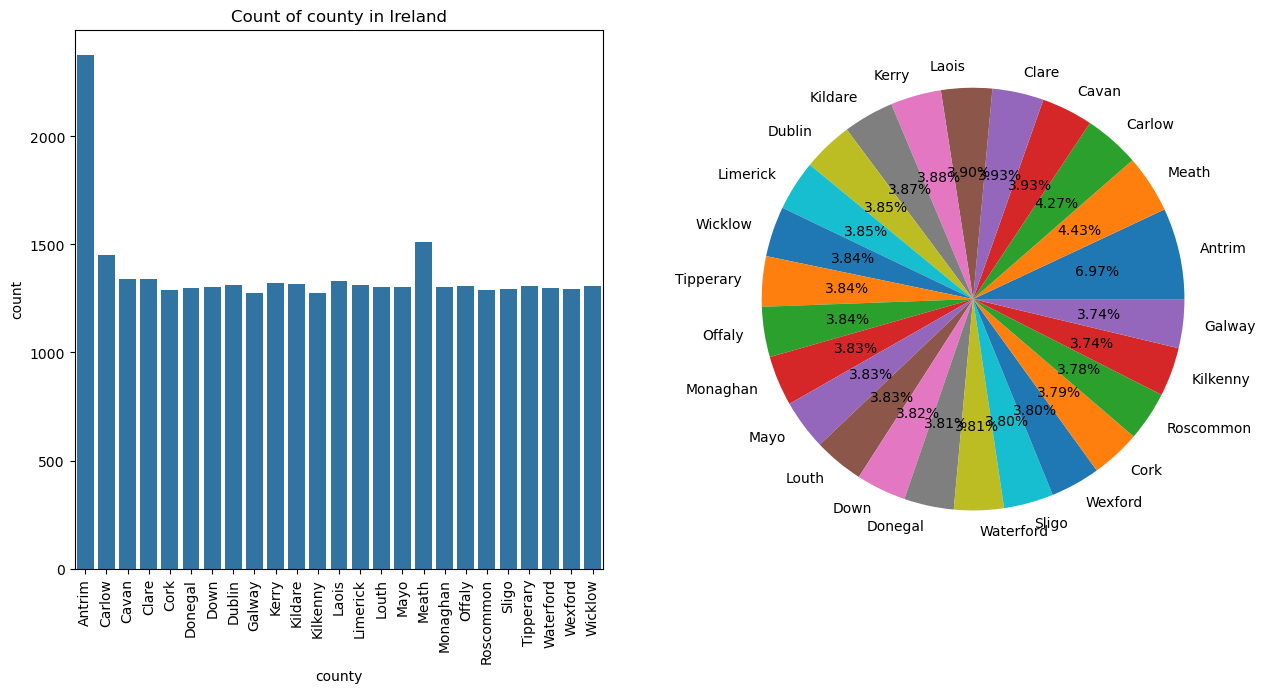

In [ ]:

fig, ax = plt.subplots(1, 2, figsize = (15, 7))
ax[0].set_title("Count of county in Ireland")
percentage = merged_df["county"].value_counts()
labels = list(merged_df["county"].value_counts().index)
sns.countplot(x = merged_df["county"], ax = ax[0])
ax[0].tick_params(axis='x', labelrotation=90)
plt.pie(percentage,labels = labels, autopct= "%0.2f%%")
plt.show()


**This graph is showing the distribution of the county column in the dataset. As we can see, Antrim has clearly the most population comparing with the other counties and its a very important part of the dataset. Meath has a relatively higher poplation in comparison to the other Counties. This is significant because if Antrim disproportionately over-represented in the data, that will skew analysis results. The data collected proves that more balanced analysis methods need to be developed in consideration of data distribution imbalances.**

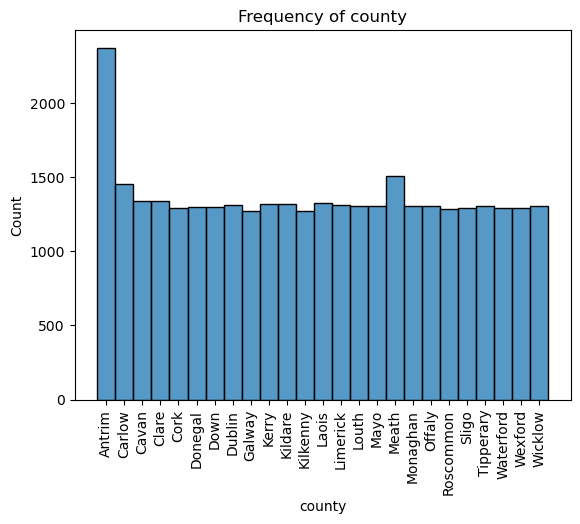

In [ ]:
#dist. of area


sns.histplot(data=merged_df, x='county', discrete=True)
plt.title('Frequency of county')

# Rotate the x-axis labels
plt.xticks(rotation=90)
plt.show()




**This visualisation looks at the breakdown of different types of waste in Ireland. There is a higher proportion of non-hazardous waste in comparison to hazardous waste. Practically two-fifths — 55.86 per cent — is on non-hazards waste while 44.14 are hazards waste, as depicted in the pie chart. This means there is a lot of hazardous waste, which should be handled and treated safely and properly. Sustainable waste management strategies should consider that differences between waste types are important for both the waste and the processes being developed for its treatment, as shown in the analysis.**

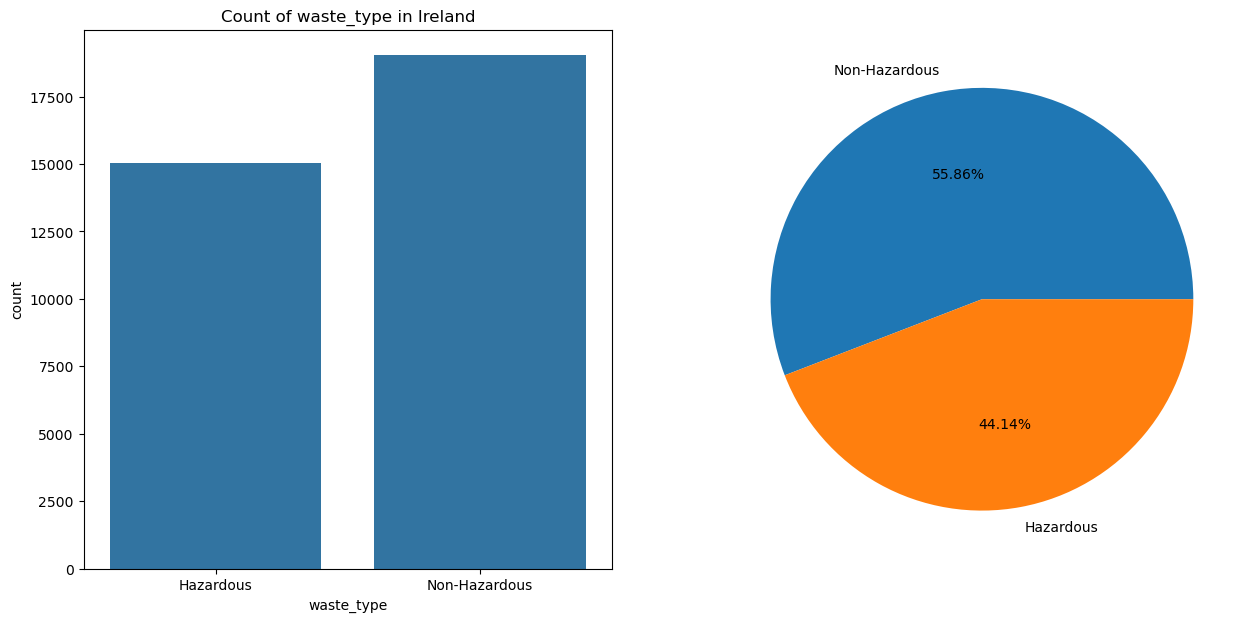

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (15, 7))
ax[0].set_title("Count of waste_type in Ireland")
percentage = merged_df["waste_type"].value_counts()
labels = list(merged_df["waste_type"].value_counts().index)
sns.countplot(x = merged_df["waste_type"], ax = ax[0])
plt.pie(percentage,labels = labels, autopct= "%0.2f%%")
plt.show()

**The number of non-hazardous waste (left) is more than hazardous waste (right). Clean and non-hazardous waste - proven by this has to deal with exclusively in waste management — which of course does not mean hazardous waste with greater safety in terms of waste management. Both types should be treated in a balanced manner, according to the analysis.**


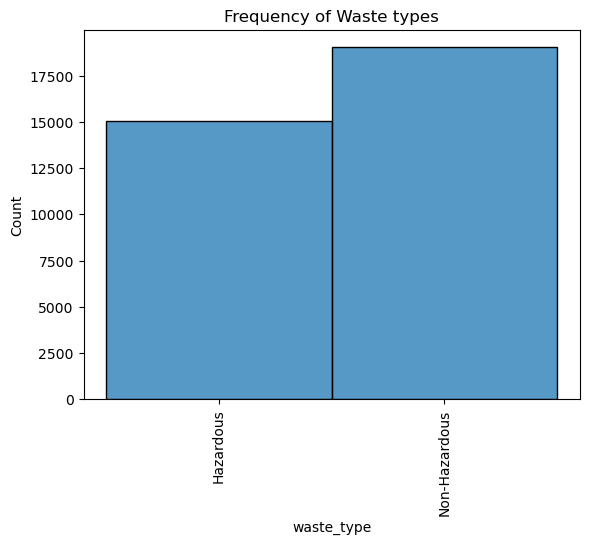

In [ ]:
#dist. of area

import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=merged_df, x='waste_type', discrete=True)
plt.title('Frequency of Waste types')

# Rotate the x-axis labels
plt.xticks(rotation=90)
plt.show()

**This visualisation shows how waste types are distributed in Ireland. The bar chart shows that the Industrial Waste category is the most highly represented compared to the other categories with 9.39%. The distribution of the other categories varies between 4% and 6%. In addition, some missing or nan data was found. This example shows that industrial waste should be prioritised and plans can be made to manage other waste types in a balanced way. Additional data should be included in the analysis.**


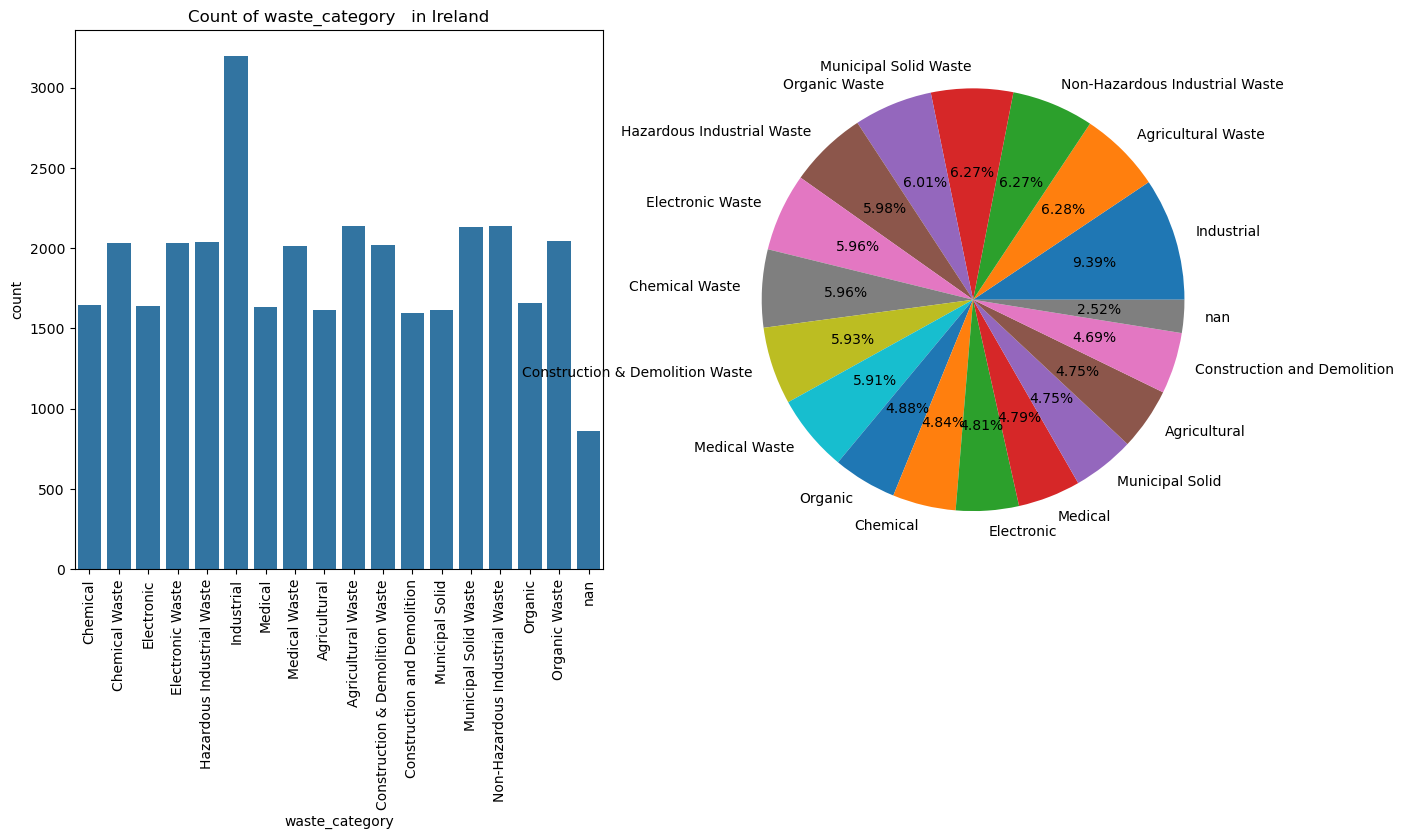

In [ ]:

fig, ax = plt.subplots(1, 2, figsize = (15, 7))
ax[0].set_title("Count of waste_category   in Ireland")
percentage = merged_df["waste_category"].value_counts()
labels = list(merged_df["waste_category"].value_counts().index)


sns.countplot(x = merged_df["waste_category"], ax = ax[0])
ax[0].tick_params(axis='x', labelrotation=90)
plt.pie(percentage,labels = labels, autopct= "%0.2f%%")
plt.show()


**This graph shows the proportion of each waste type in Ireland. The most frequent category is again of industrial waste, which is overrepresented compared to any other category. Most categories are evenly spread out, except for the nan representing the missing data. This underlines once again the need to consider industrial waste in missing data analysis.**

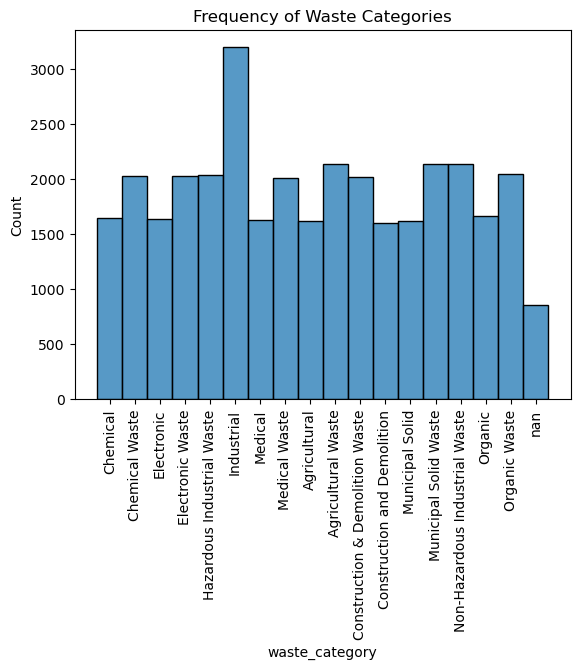

In [ ]:
sns.histplot(data=merged_df, x='waste_category', discrete=True)
plt.title('Frequency of Waste Categories')

# Rotate the x-axis labels
plt.xticks(rotation=90)
plt.show()


# Analysis on continuous  columns    

In [ ]:
from tabulate import tabulate
table = [categorical, continuous]
print(tabulate({"Categorical":categorical,"continuous": continuous}, headers = 'keys'))

Categorical     continuous
--------------  --------------------------------
county          quarter
waste_type      waste_generated_(tonnes)
waste_category  waste_treated_(tonnes)
                price_of_treatment_(€_per_tonne)
                key


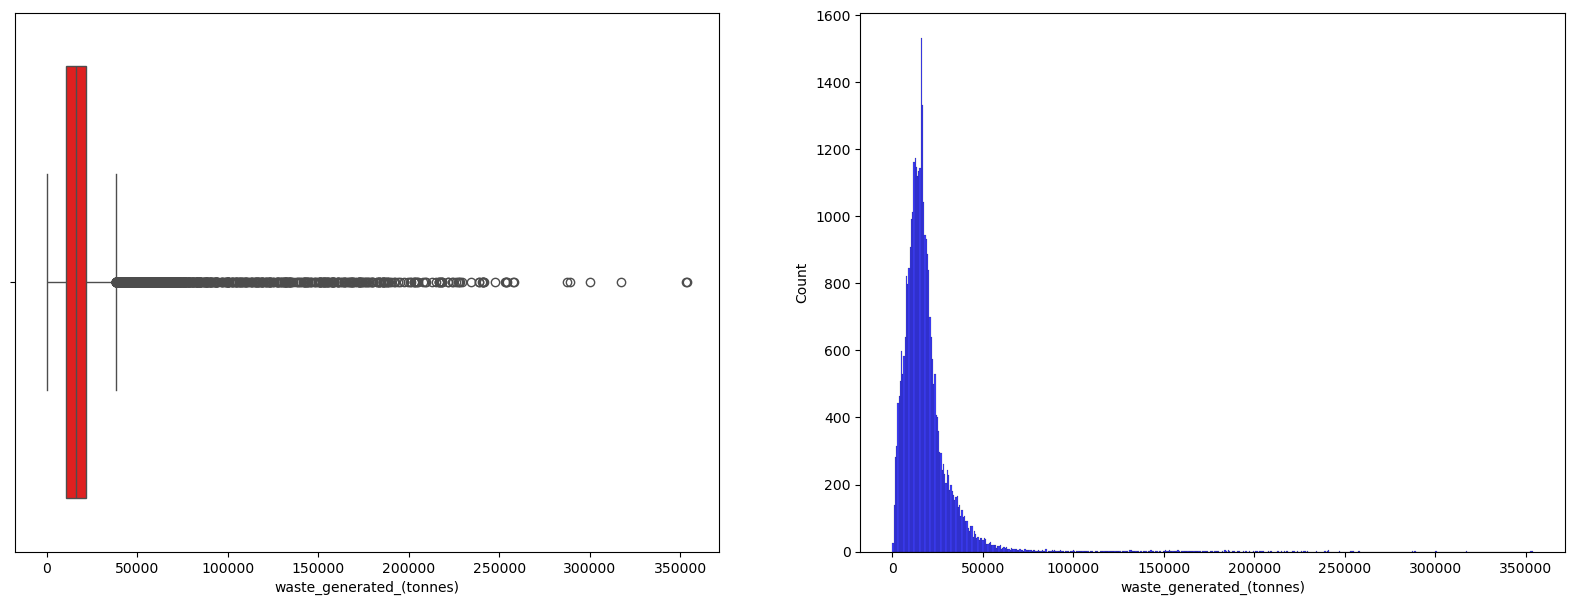

In [ ]:
fig, ax = plt.subplots(1, 2, figsize= (20, 7))
sns.histplot(x = merged_df['waste_generated_(tonnes)'], ax =ax[1], color = "b")
sns.boxplot(x = merged_df['waste_generated_(tonnes)'], ax = ax[0], color = "r")
plt.show()

Left (Boxplot): The boxplot shows, in tonnes, the difference in terms of the amount of waste that is generated on average. The part of the distribution that holds the middlemost data and the fastest growth of data outward from either side are one medium and one fairly large outlier. The majority of waste found in each company falls within the interquartile range. On the other hand, quite a few spread far behind, representing so-called extreme cases of waste production. It clearly initiates yourself at the presence of numerous huge outliers, because some investigation should be carried out further in order to understand why some entities generate substantially more waste in comparison to the record.

Right (Histogram): The histogram represents frequency distribution of waste in waste generated in tonnes. Most values cluster toward the lower end of the range, indicating that most entities generate very small amounts of waste. The great fall of speed as how massive waste is generated gives reason to believe that remarkable waste generation is rare. As this frequency slide goes down towards higher waste generation, it is noticeable that there exist many high-waste-generating points with these high frequencies, corroborated by the outliers.

In [ ]:
fixing outliers using quartiles

In [ ]:
merged_df['waste_generated_(tonnes)'].describe()



count     34060.000000
mean      18750.316045
std       17313.945857
min           1.205412
25%       10656.242500
50%       15838.890000
75%       21729.005000
max      354022.600000
Name: waste_generated_(tonnes), dtype: float64

In [ ]:
#outlier analysis

q1=10656.242500
q3=21729.005000
iqr=q3-q1
Uquartile=q3+1.5*iqr
Lquartile=q3-1.5*iqr
Uquartile



x = merged_df[merged_df['waste_generated_(tonnes)'] > Uquartile].index
for index in x:
    merged_df.loc[index, 'waste_generated_(tonnes)'] = 18750.316045

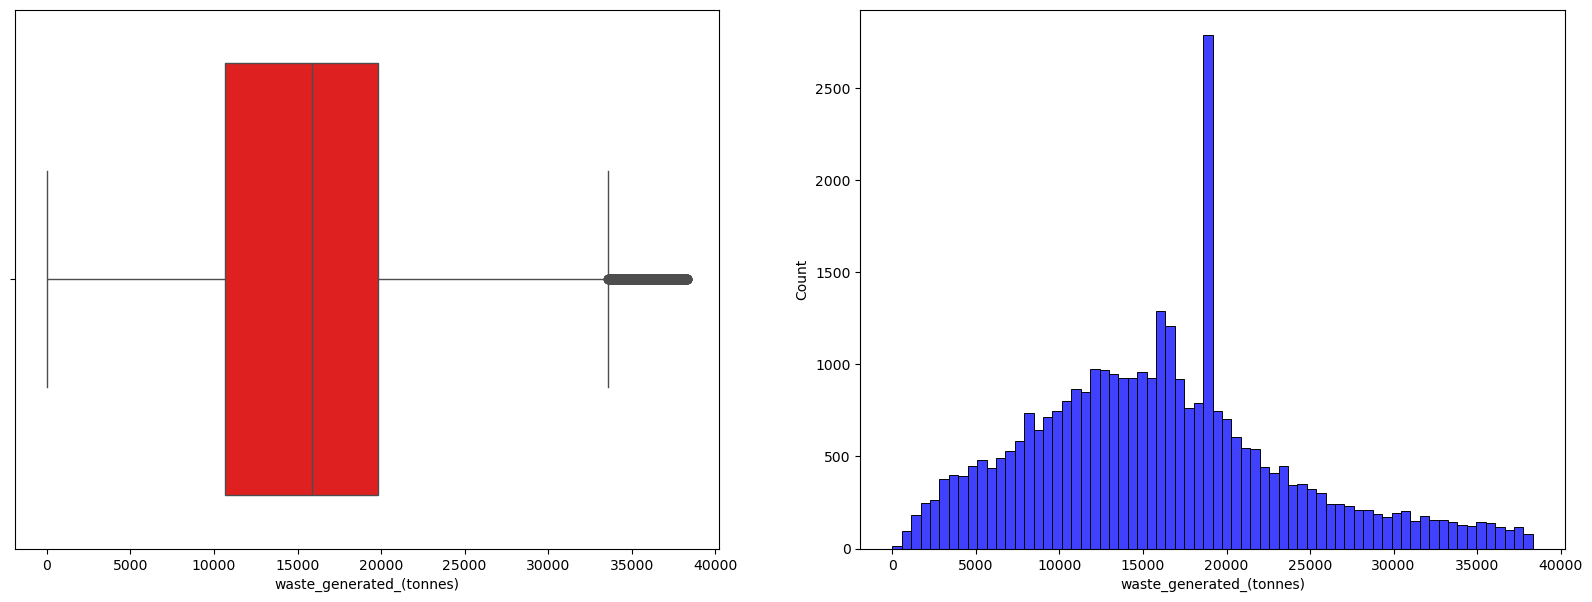

In [ ]:
fig, ax = plt.subplots(1, 2, figsize= (20, 7))
sns.histplot(x = merged_df['waste_generated_(tonnes)'], ax =ax[1], color = "b")
sns.boxplot(x = merged_df['waste_generated_(tonnes)'], ax = ax[0], color = "r")
plt.show()

Box plot (Left): As the figure suggests, waste disposal in tonnes is distributed along a given line and illustrated across the center, where the majority of data lie. Measurements remain constant between the quartiles. Due to the void of any outlier, the data indicates that immensely variant waste disposal amounts are commonly rare. It is one of the reasons for considering other activities of waste management to be conducted in a similar pattern across all facilities.

Histogram (Right): The sequential graph shows frequency distribution of waste treatment in entities and its apex is at about 20,000 tonnes. This means most entities deal with nearly similar quantities of waste treatment. Further, this decline, both on the left and right sides, shows that a very small percentage of entities have a treatment bill that is very low or very high.

Both showcases and mirror each other on a larger scale as both follow set and common conservative limits about waste treatment capacities which involve most of the institutions. Such similar practices are also encouraged by structured treatment capacities of entities or instructions that stigmatize differential practice variations.

In [ ]:
waste_treated_(tonnes)

In [ ]:
merged_df['waste_treated_(tonnes)'].describe()




count     34060.000000
mean      17806.873202
std       16258.968597
min           1.205412
25%       10145.322000
50%       14721.138000
75%       20666.524500
max      318620.340000
Name: waste_treated_(tonnes), dtype: float64

In [ ]:
#outlier analysis

q1=10145.322000
q3=20666.524500
iqr=q3-q1
Uquartile=q3+1.5*iqr
Lquartile=q3-1.5*iqr
Uquartile



x = merged_df[merged_df['waste_treated_(tonnes)'] > Uquartile].index
for index in x:
    merged_df.loc[index, 'waste_treated_(tonnes)'] = 17806.873202

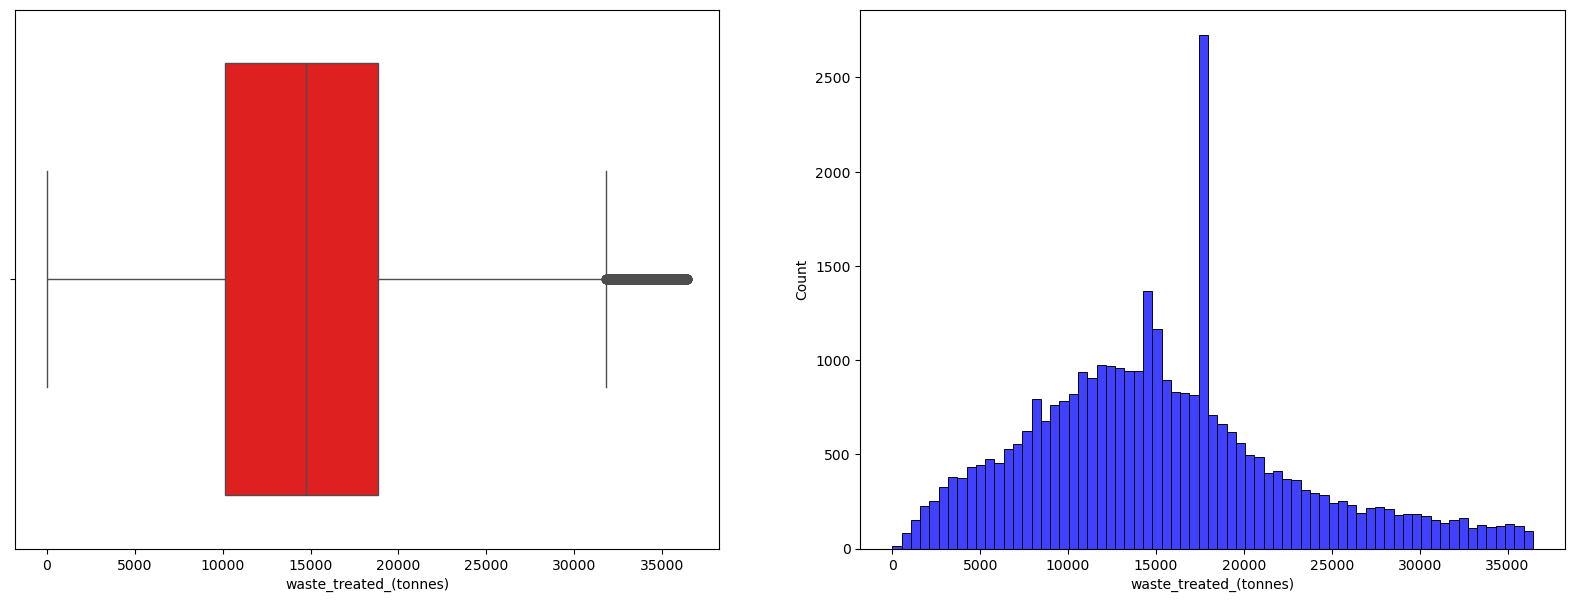

In [ ]:
fig, ax = plt.subplots(1, 2, figsize= (20, 7))
sns.histplot(x = merged_df['waste_treated_(tonnes)'], ax =ax[1], color = "b")
sns.boxplot(x = merged_df['waste_treated_(tonnes)'], ax = ax[0], color = "r")
plt.show()

Boxplot (Left): An improvement is shown in the boxplot in terms of the distribution of garbage treatment reaching tonnes. It can be noted that it has a narrower range of  tonnes than in the earlier version, apparently, the extreme values have been replaced or adjusted. Despite such transformations, the IQR still embraces most of the patterns but, with fewest values at the extreme.

Histogram (Right): The histogram demonstrates the frequency distribution of waste treatment and has a clear peak at 15 000–20 000 tonnes. Lessening the smoothness on the historical distribution and narrowing the spread elsewhere bear witness to the impact of the outliers been addressed. There is discernible tightening in the clustering of data.

These new visual representations show a marked improvement in the consistency of the waste treatment data set as it is more suitable for analysis and decision-making without the distortion caused by significant values.

In [ ]:
price_of_treatment_(€_per_tonne)

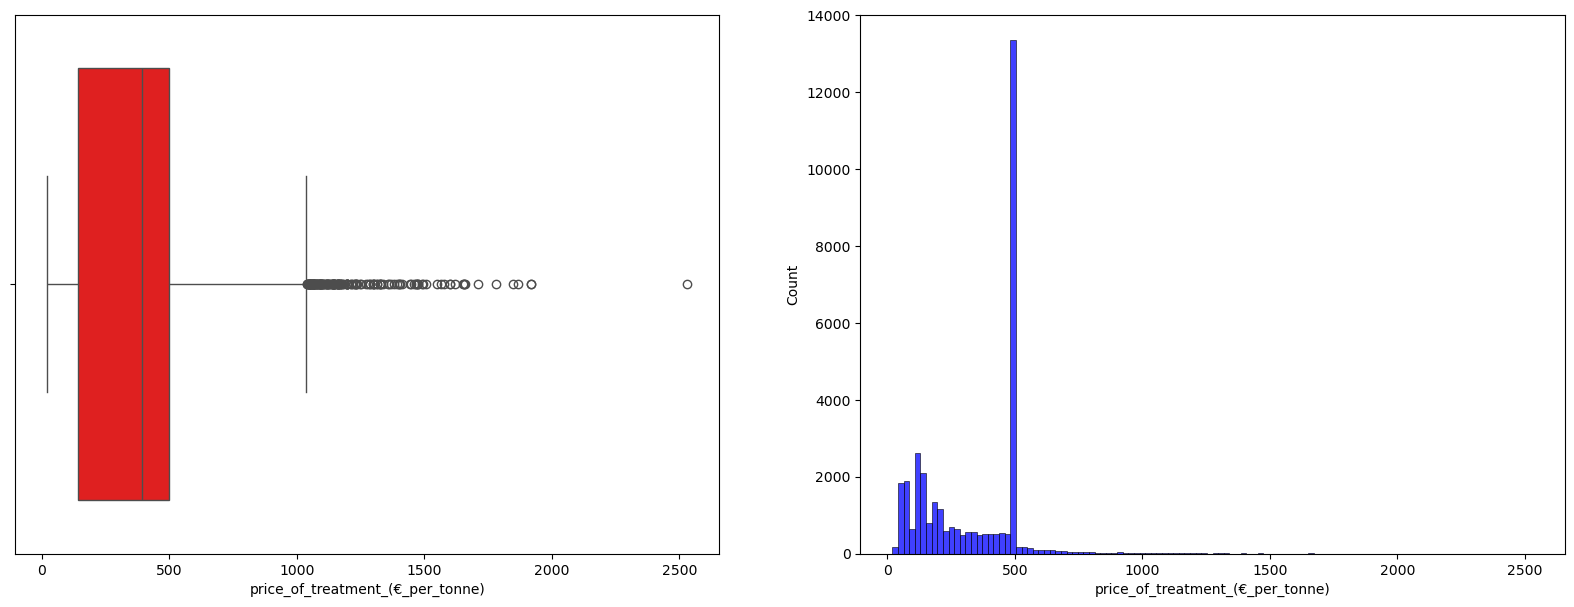

In [ ]:
fig, ax = plt.subplots(1, 2, figsize= (20, 7))
sns.histplot(x = merged_df['price_of_treatment_(€_per_tonne)'], ax =ax[1], color = "b")
sns.boxplot(x = merged_df['price_of_treatment_(€_per_tonne)'], ax = ax[0], color = "r")
plt.show()

This visualization analyzes the data of price_of_treatment_ symbols (€ per ton), displaying the data distributions and significant variations. Most of the values grouped within the range of € 100–€ 300 make it possible to discern such clustering in a histogram or a box plot. It seems pricing is quite standard; most organizations charge about the same price. However, few very high values from €1,500 to almost €2,500 will probably need intense scrutiny into the cost of the most expensive above-average cases. This highlights the general conformity of pricing in treatment, ever-so-slight variances that could change the average price significantly and so, in many cases, merit specific attention.

In [ ]:
merged_df['price_of_treatment_(€_per_tonne)'].describe()




count    34060.000000
mean       341.148284
std        196.812805
min         20.000000
25%        141.227904
50%        393.748751
75%        500.000000
max       2531.015583
Name: price_of_treatment_(€_per_tonne), dtype: float64

In [ ]:
#outlier analysis

q1=141.227904
q3=500.000000
iqr=q3-q1
Uquartile=q3+1.5*iqr
Lquartile=q3-1.5*iqr
Uquartile



x = merged_df[merged_df['price_of_treatment_(€_per_tonne)'] > Uquartile].index
for index in x:
    merged_df.loc[index, 'price_of_treatment_(€_per_tonne)'] = 17806.873202

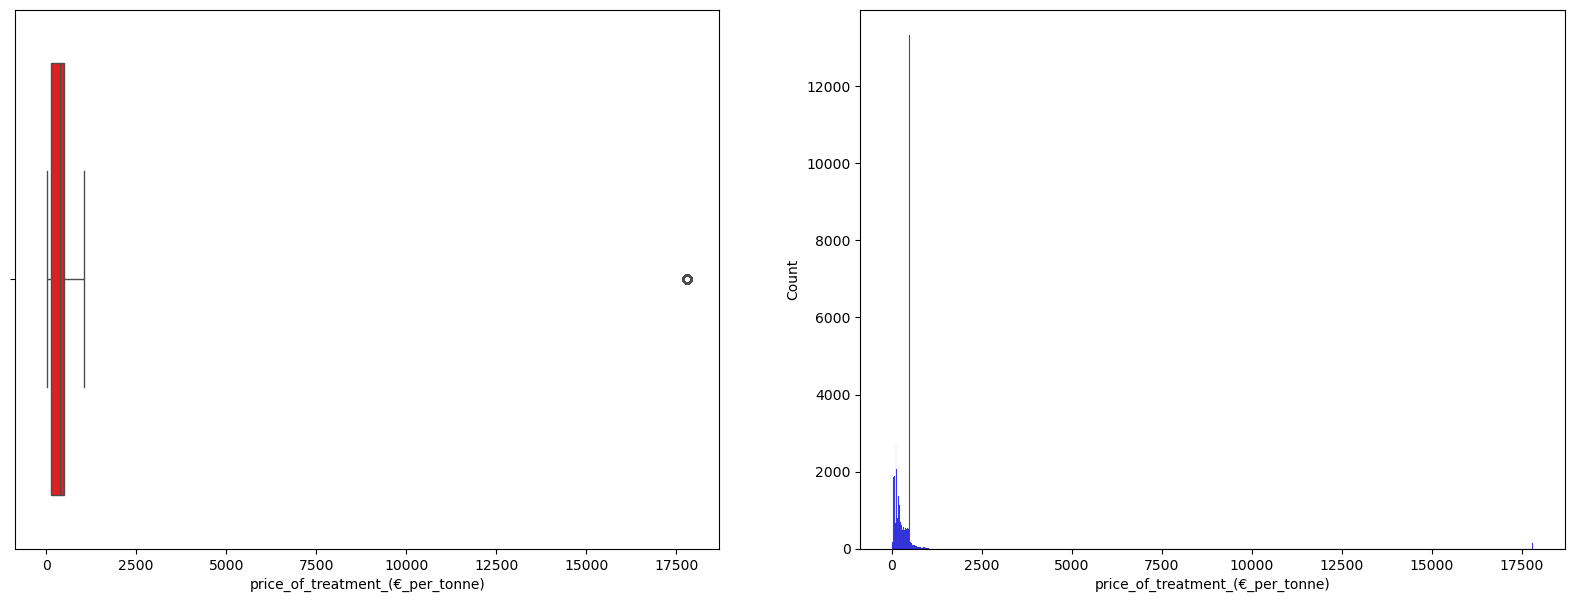

In [ ]:
fig, ax = plt.subplots(1, 2, figsize= (20, 7))
sns.histplot(x = merged_df['price_of_treatment_(€_per_tonne)'], ax =ax[1], color = "b")
sns.boxplot(x = merged_df['price_of_treatment_(€_per_tonne)'], ax = ax[0], color = "r")
plt.show()

Overall, most of the treatments are within the 100–300 euro range, it emerges through a histogram and boxplot. As per the box plot, it seems that most pricing trends are constant across most of the data points; nevertheless, the histogram is a smoother distribution as compared to the original version. There are outliers; they are in fact quite often reduced in the most recent issue up to 17,500 euros. It would, however, be good to test whether these outliers are exceptional extreme cases, which could have very considerable consequences on the average costs or other budgetary decisions.

Therefore, this refined analysis also reveals consistency in pricing across datasets, and simultaneously reminds us to explore some rare scenarios in megacost.

## since all the outliers are treated. lets create two calculated fields

In [ ]:


# Step 1: Calculate the percentage of waste treated for each row
merged_df['waste_treated_percentage'] = (
    merged_df['waste_treated_(tonnes)'] / merged_df['waste_generated_(tonnes)'] * 100
)

# Step 2: Print the first few rows to verify the calculation
print(merged_df[['waste_generated_(tonnes)', 'waste_treated_(tonnes)', 'waste_treated_percentage']].head())


   waste_generated_(tonnes)  waste_treated_(tonnes)  waste_treated_percentage
0              16481.598594            14833.438734                      90.0
1              16975.100000            16975.100000                     100.0
2              31349.450000            28214.505000                      90.0
3              14926.920000            14926.920000                     100.0
4              21736.960000            21736.960000                     100.0


In [ ]:
# creating a calculation field to find the treatment efficiency
# Calculate Treatment Efficiency including price of treatment
merged_df['treatment_efficiency'] = (
    (merged_df['waste_treated_(tonnes)'] / merged_df['waste_generated_(tonnes)']) *
    merged_df['price_of_treatment_(€_per_tonne)']
)

# Normalize the values by capping at 100%
merged_df['treatment_efficiency'] = merged_df['treatment_efficiency'].clip(0, 100)

# Print the first few rows to verify the calculation
print(merged_df[['waste_generated_(tonnes)', 'waste_treated_(tonnes)', 'price_of_treatment_(€_per_tonne)', 'treatment_efficiency']].head())


   waste_generated_(tonnes)  waste_treated_(tonnes)  \
0              16481.598594            14833.438734   
1              16975.100000            16975.100000   
2              31349.450000            28214.505000   
3              14926.920000            14926.920000   
4              21736.960000            21736.960000   

   price_of_treatment_(€_per_tonne)  treatment_efficiency  
0                        500.000000                 100.0  
1                        683.436906                 100.0  
2                        500.000000                 100.0  
3                         69.000000                  69.0  
4                        720.118493                 100.0  


In [ ]:
merged_df

,quarter,county,waste_type,waste_category,waste_generated_(tonnes),waste_treated_(tonnes),price_of_treatment_(€_per_tonne),waste_treated_percentage,treatment_efficiency
0,2004 Q1,Antrim,Hazardous,Chemical,16481.598594,14833.438734,500.000000,90.0,100.0
1,2004 Q1,Antrim,Hazardous,Chemical Waste,16975.100000,16975.100000,683.436906,100.0,100.0
2,2004 Q1,Antrim,Hazardous,Electronic,31349.450000,28214.505000,500.000000,90.0,100.0
3,2004 Q1,Antrim,Hazardous,Electronic Waste,14926.920000,14926.920000,69.000000,100.0,69.0
4,2004 Q1,Antrim,Hazardous,Hazardous Industrial Waste,21736.960000,21736.960000,720.118493,100.0,100.0
...,...,...,...,...,...,...,...,...,...
34055,2024 Q4,Antrim,Non-Hazardous,Construction & Demolition Waste,7397.810000,7397.810000,105.590000,100.0,100.0
34056,2024 Q4,Antrim,Non-Hazardous,Industrial,13717.360000,12345.624000,500.000000,90.0,100.0
34057,2024 Q4,Antrim,Non-Hazardous,Municipal Solid Waste,4861.820000,4861.820000,116.699483,100.0,100.0
34058,2024 Q4,Antrim,Non-Hazardous,Organic,18843.450000,16959.105000,500.000000,90.0,100.0


In [ ]:
 merged_df.duplicated(keep = False)

0        False
1        False
2        False
3        False
4        False
         ...  
34055    False
34056    False
34057    False
34058    False
34059    False
Length: 34060, dtype: bool

# Exploratory data analysis

In [ ]:
categorical, continuous

(['county', 'waste_type', 'waste_category'],
 ['quarter',
  'waste_generated_(tonnes)',
  'waste_treated_(tonnes)',
  'price_of_treatment_(€_per_tonne)',
  'key'])

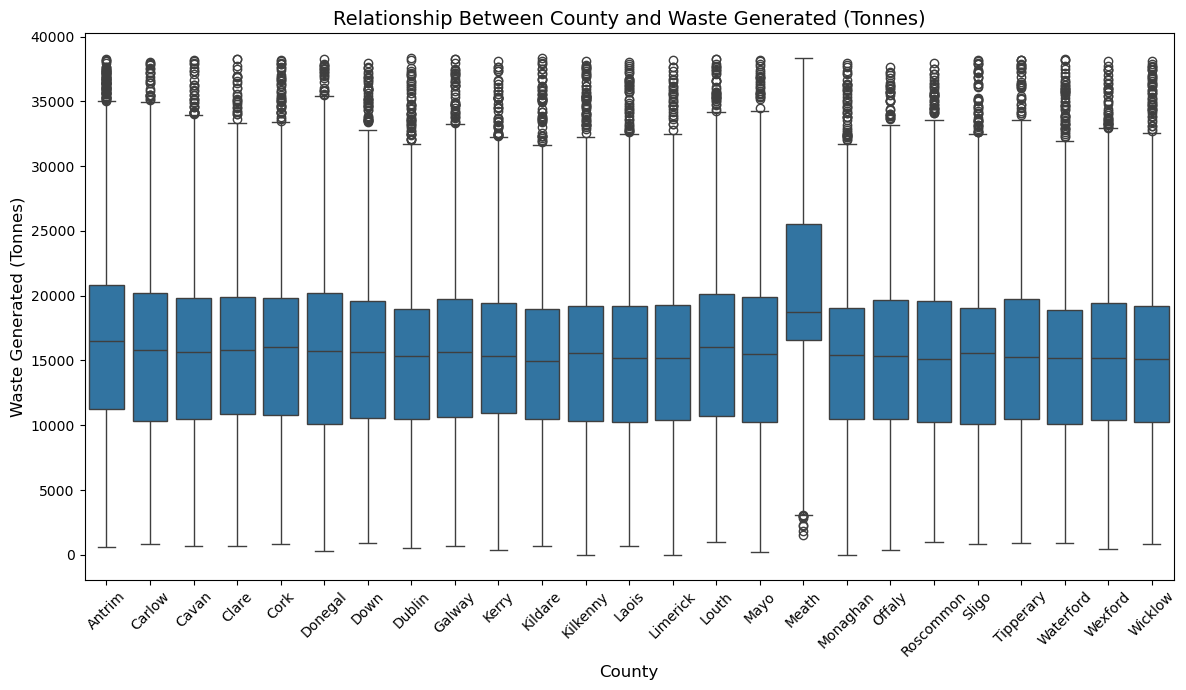

In [ ]:


# Relationship between county and waste generated
plt.figure(figsize=(12, 7))
sns.boxplot(x='county', y='waste_generated_(tonnes)', data=merged_df)
plt.xticks(rotation=45)  # Or plt.xticks(rotation=90) for vertical labels
plt.title('Relationship Between County and Waste Generated (Tonnes)', fontsize=14)
plt.xlabel('County', fontsize=12)
plt.ylabel('Waste Generated (Tonnes)', fontsize=12)
plt.tight_layout()
plt.show()



 **This is a box plot: The x axis of your plot shows the Irish counties, while the y axis shows the number of tonnes per each Irish county. To better represent the total waste distributed over the 26 counties of Ireland, we created the above graph which illustrates high median waste generation from Mayo, and an overall larger variation in its data compared to most other counties saturating around generating between 10,000 to 20,000 tonnes of waste. Each box plot shows the median, quartiles, and extreme points (shown as dots) of waste generation in each county, where blue boxes represent the interquartile range and the whiskers of the box plot extend to the maximum and minimum values, excluding outliers.**

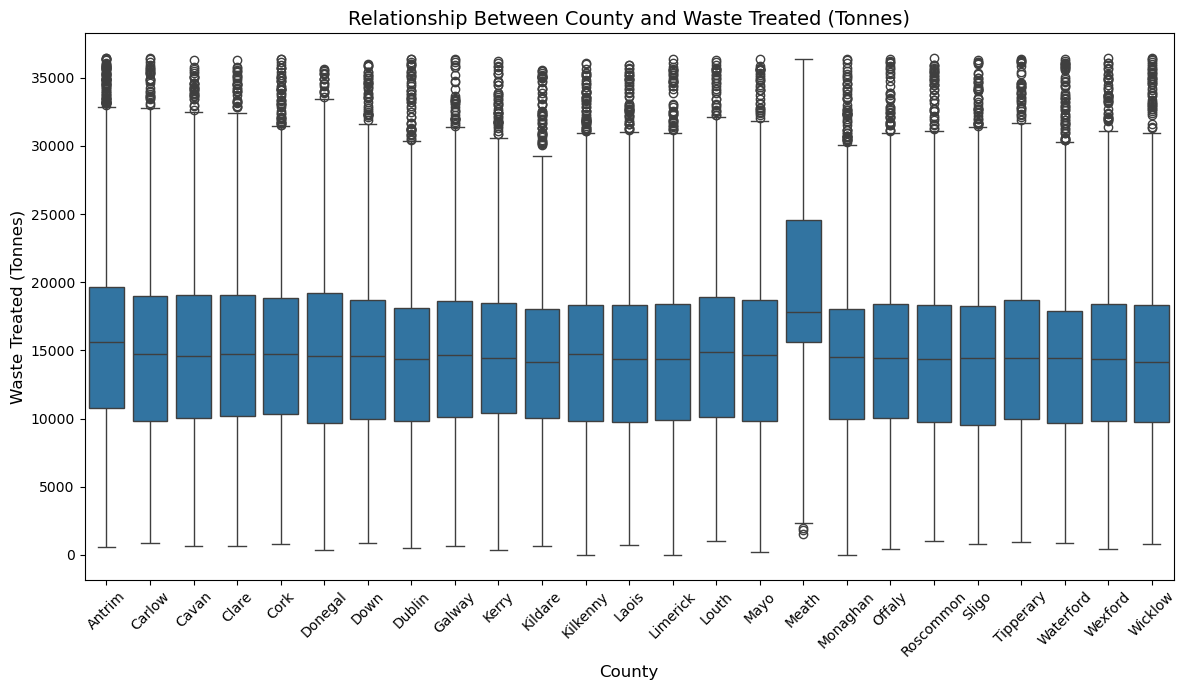

In [ ]:
# Relationship between county and waste treated
plt.figure(figsize=(12, 7))
sns.boxplot(x='county', y='waste_treated_(tonnes)', data=merged_df)  # Fixed column name
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.title('Relationship Between County and Waste Treated (Tonnes)', fontsize=14)  # Updated title
plt.xlabel('County', fontsize=12)
plt.ylabel('Waste Treated (Tonnes)', fontsize=12)
plt.tight_layout()  # Prevent label overlap
plt.show()


**The relation between Irish counties with waste treated in tonnes is depicted in this box plot, indicating the variation of waste treated across the different counties in Ireland. Boxes represent the corresponding statistical distribution of treated waste, where blue boxes show interquartile range (IQR), vertical lines (whiskers) extend to the minimum and maximum values, the horizontal line within box shows median value. Mayo shows by far the biggest spread and median in terms of waste treatment numbers, whereas the remaining counties give fairly similar ranges, with the exception of one or two outliers at the 10,000 - 20,000 tonne level of waste treated.**

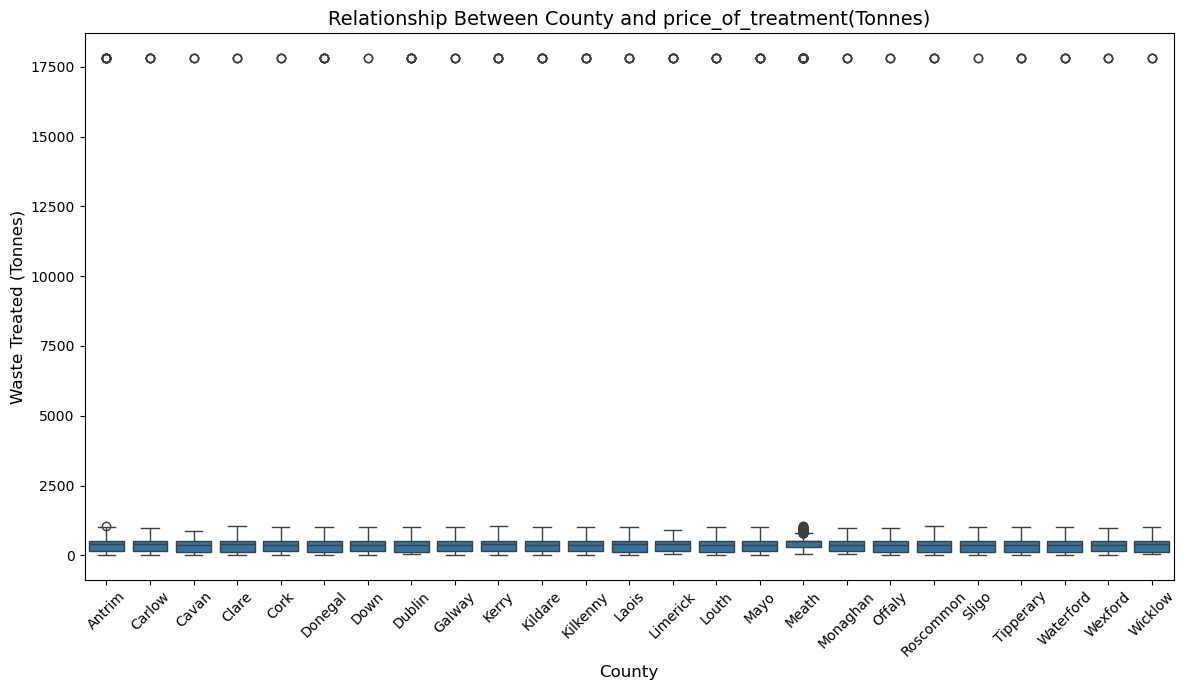

In [ ]:
# Relationship between county and waste treated
plt.figure(figsize=(12, 7))
sns.boxplot(x='county', y='price_of_treatment_(€_per_tonne)', data=merged_df)  # Fixed column name
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.title('Relationship Between County and price_of_treatment(Tonnes)', fontsize=14)  # Updated title
plt.xlabel('County', fontsize=12)
plt.ylabel('Waste Treated (Tonnes)', fontsize=12)
plt.tight_layout()  # Prevent label overlap
plt.show()


**This box plot demonstrates the association between Irish counties and the variety of waste processed in a unit of tonnes. Reproducing again the pattern for all counties, most values clump together in a fairly small area low on the scale (0 - 1000 tonnes) yet each county has an excess of outliers at roughly 17,500 tonnes indicated by circles. Overall, the Most waste treatment operations deal with a similar if relatively small volumes while much larger treatment volumes vary across all counties.**

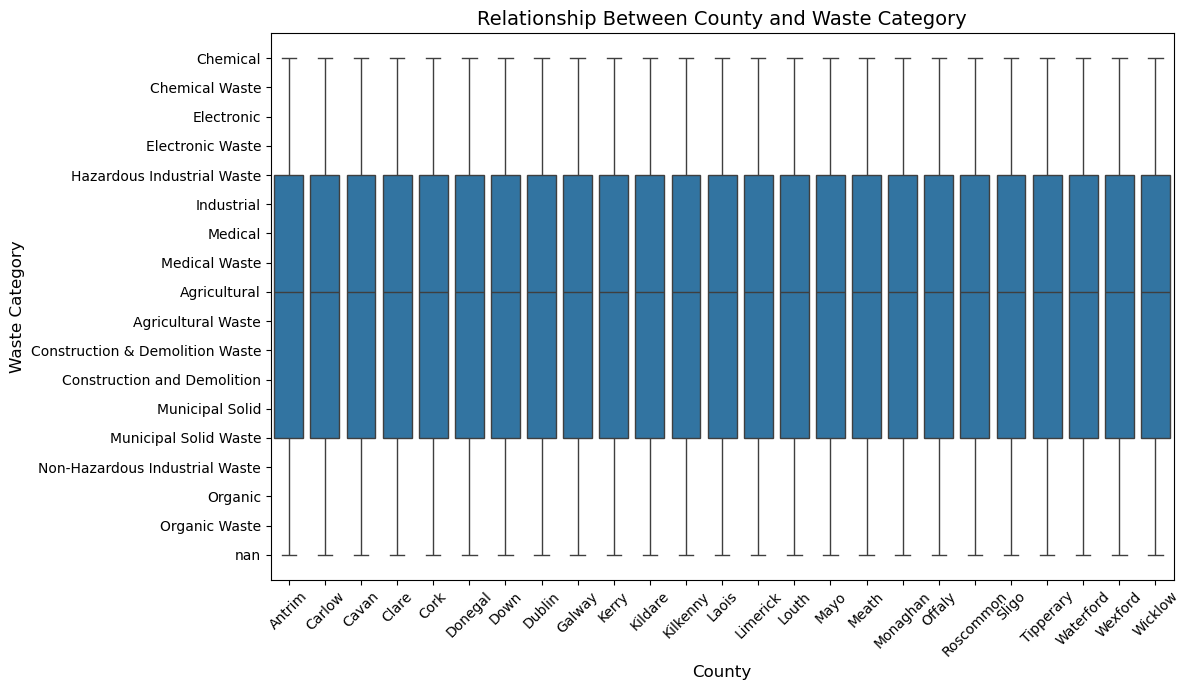

In [ ]:
# Relationship between county and waste category
plt.figure(figsize=(12, 7))

# Correct column names and ensure they exist in the DataFrame
sns.boxplot(x='county', y='waste_category', data=merged_df)
plt.xticks(rotation=45)
# Update title and axis labels to match the data being plotted
plt.title('Relationship Between County and Waste Category', fontsize=14)
plt.xlabel('County', fontsize=12)
plt.ylabel('Waste Category', fontsize=12)

# Prevent label overlap and show the plot
plt.tight_layout()
plt.show()


**A graph indicating the waste type in a county, lined in point form with a slight resemblance to Ireland This visualization also uses the horizontal bar chart format but uses the rows for the Waste Categories (Hazardous Industrial Waste, Industrial, Medical, Agricultural, Construction & Demolition and Municipal Solid Waste) and the columns for different Irsh counties (like Antrim, Carlow, Cavan etc). The filled blue bars suggest that certain categories of waste are consistently present or tracked across all counties, whereas empty or unfilled categories, such as Chemical, Electronic, and Organic waste, indicate that these types are not being tracked or present in these jurisdictions.**

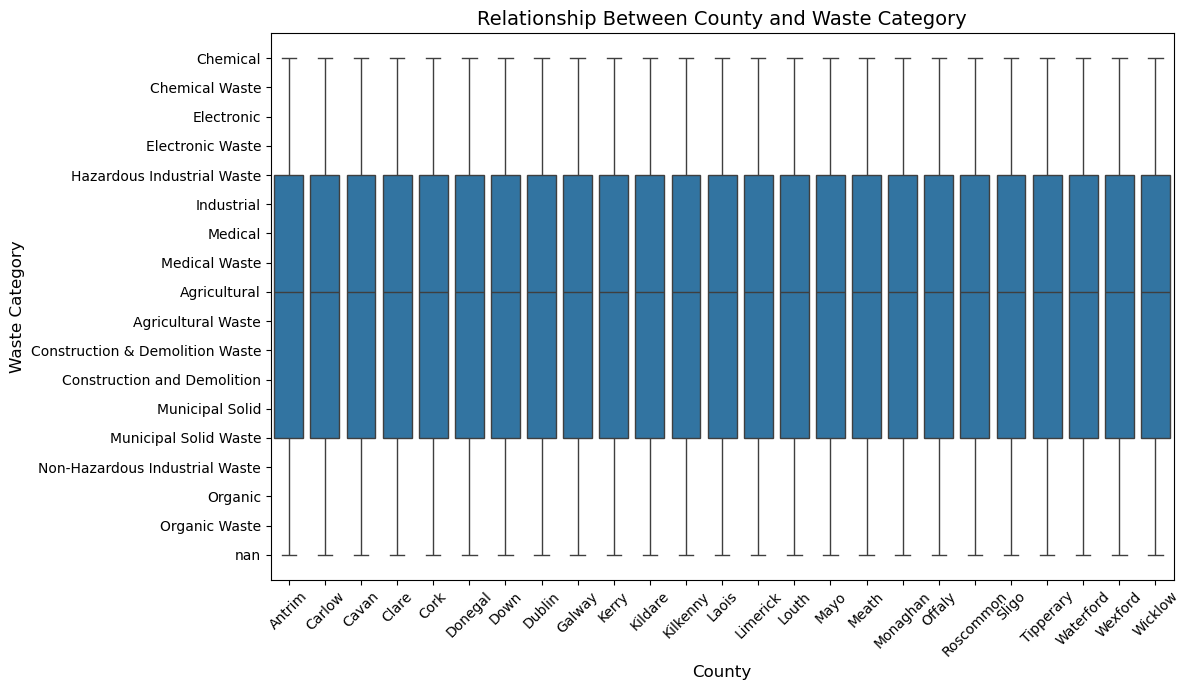

In [ ]:
# Relationship between county and waste category
plt.figure(figsize=(12, 7))

# Correct column names and ensure they exist in the DataFrame
sns.boxplot(x='county', y='waste_category', data=merged_df)
plt.xticks(rotation=45)
# Update title and axis labels to match the data being plotted
plt.title('Relationship Between County and Waste Category', fontsize=14)
plt.xlabel('County', fontsize=12)
plt.ylabel('Waste Category', fontsize=12)

# Prevent label overlap and show the plot
plt.tight_layout()
plt.show()


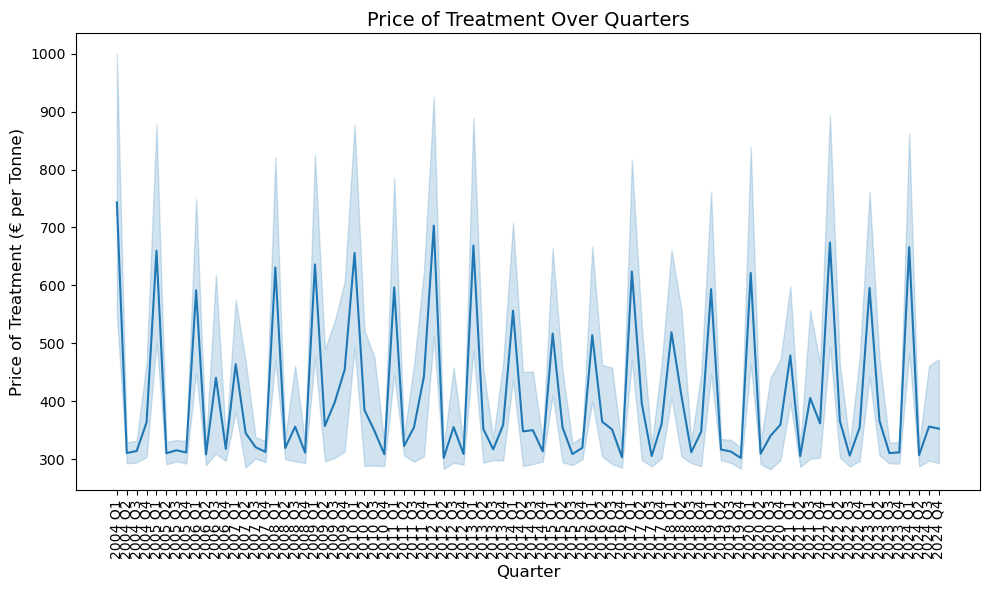

In [ ]:


# Line plot showing the relationship between quarter and price of treatment
plt.figure(figsize=(10, 6))

# Use seaborn lineplot
sns.lineplot(x='quarter', y='price_of_treatment_(€_per_tonne)', data=merged_df)

# Add a title and axis labels
plt.title('Price of Treatment Over Quarters', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Price of Treatment (€ per Tonne)', fontsize=12)

# Customize x-axis: rotate and limit ticks
plt.xticks(rotation=90)  # Rotate labels
plt.locator_params(axis='x', nbins=10)  # Limit number of ticks (e.g., 10)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


**Quarters of price fluctuations for treatment costs per tonne, ranging from €300 to €900 as shown in this graph. The data includes obvious cycles and peaks and troughs at consistent intervals over the time series, indicating treatment price seasonality or periodicity. The confidence interval band (in light blue) runs around the main trend line (in dark blue), showing how variable or uncertain the price measurements were between the different quarters**

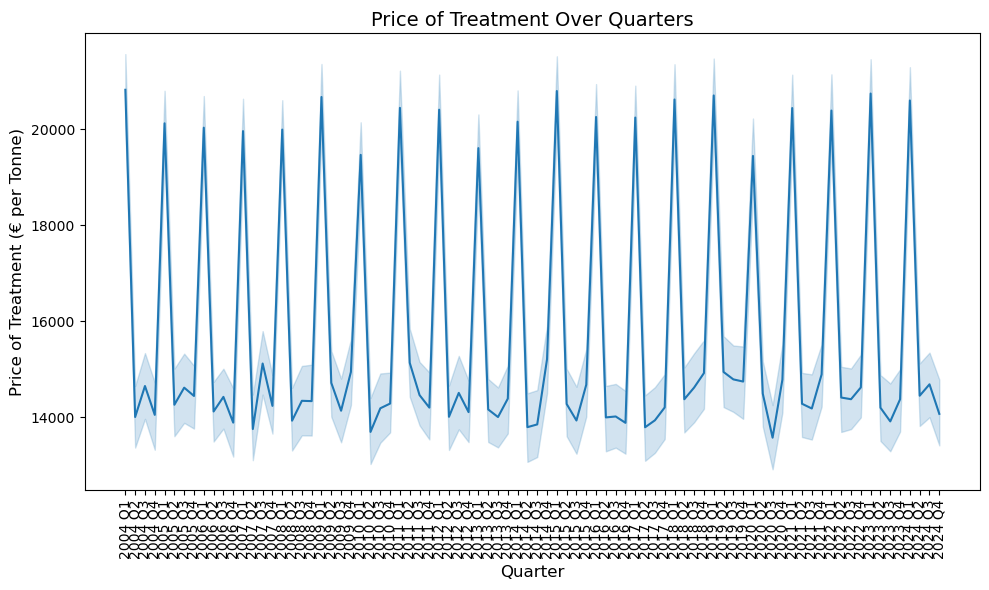

In [ ]:
# Line plot showing the relationship between quarter and price of treatment
plt.figure(figsize=(10, 6))

# Use seaborn lineplot
sns.lineplot(x='quarter', y='waste_generated_(tonnes)', data=merged_df)

# Add a title and axis labels
plt.title('Price of Treatment Over Quarters', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Price of Treatment (€ per Tonne)', fontsize=12)

# Customize x-axis: rotate and limit ticks
plt.xticks(rotation=90)  # Rotate labels
plt.locator_params(axis='x', nbins=20)  # Limit number of ticks (e.g., 10)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


**Pricing Costs Graph for a Treatment Cost in Euros per Tonne across Quarters The price is cyclical in nature, with peaks reaching € 20,000 and troughs (in the shorter term) of around € 14,000 all the time. The precedent looks like it continues that oscillating around the time period, with some kind of measure of uncertainty or variance of the measurements as a shaded area this last for the entire time series.**

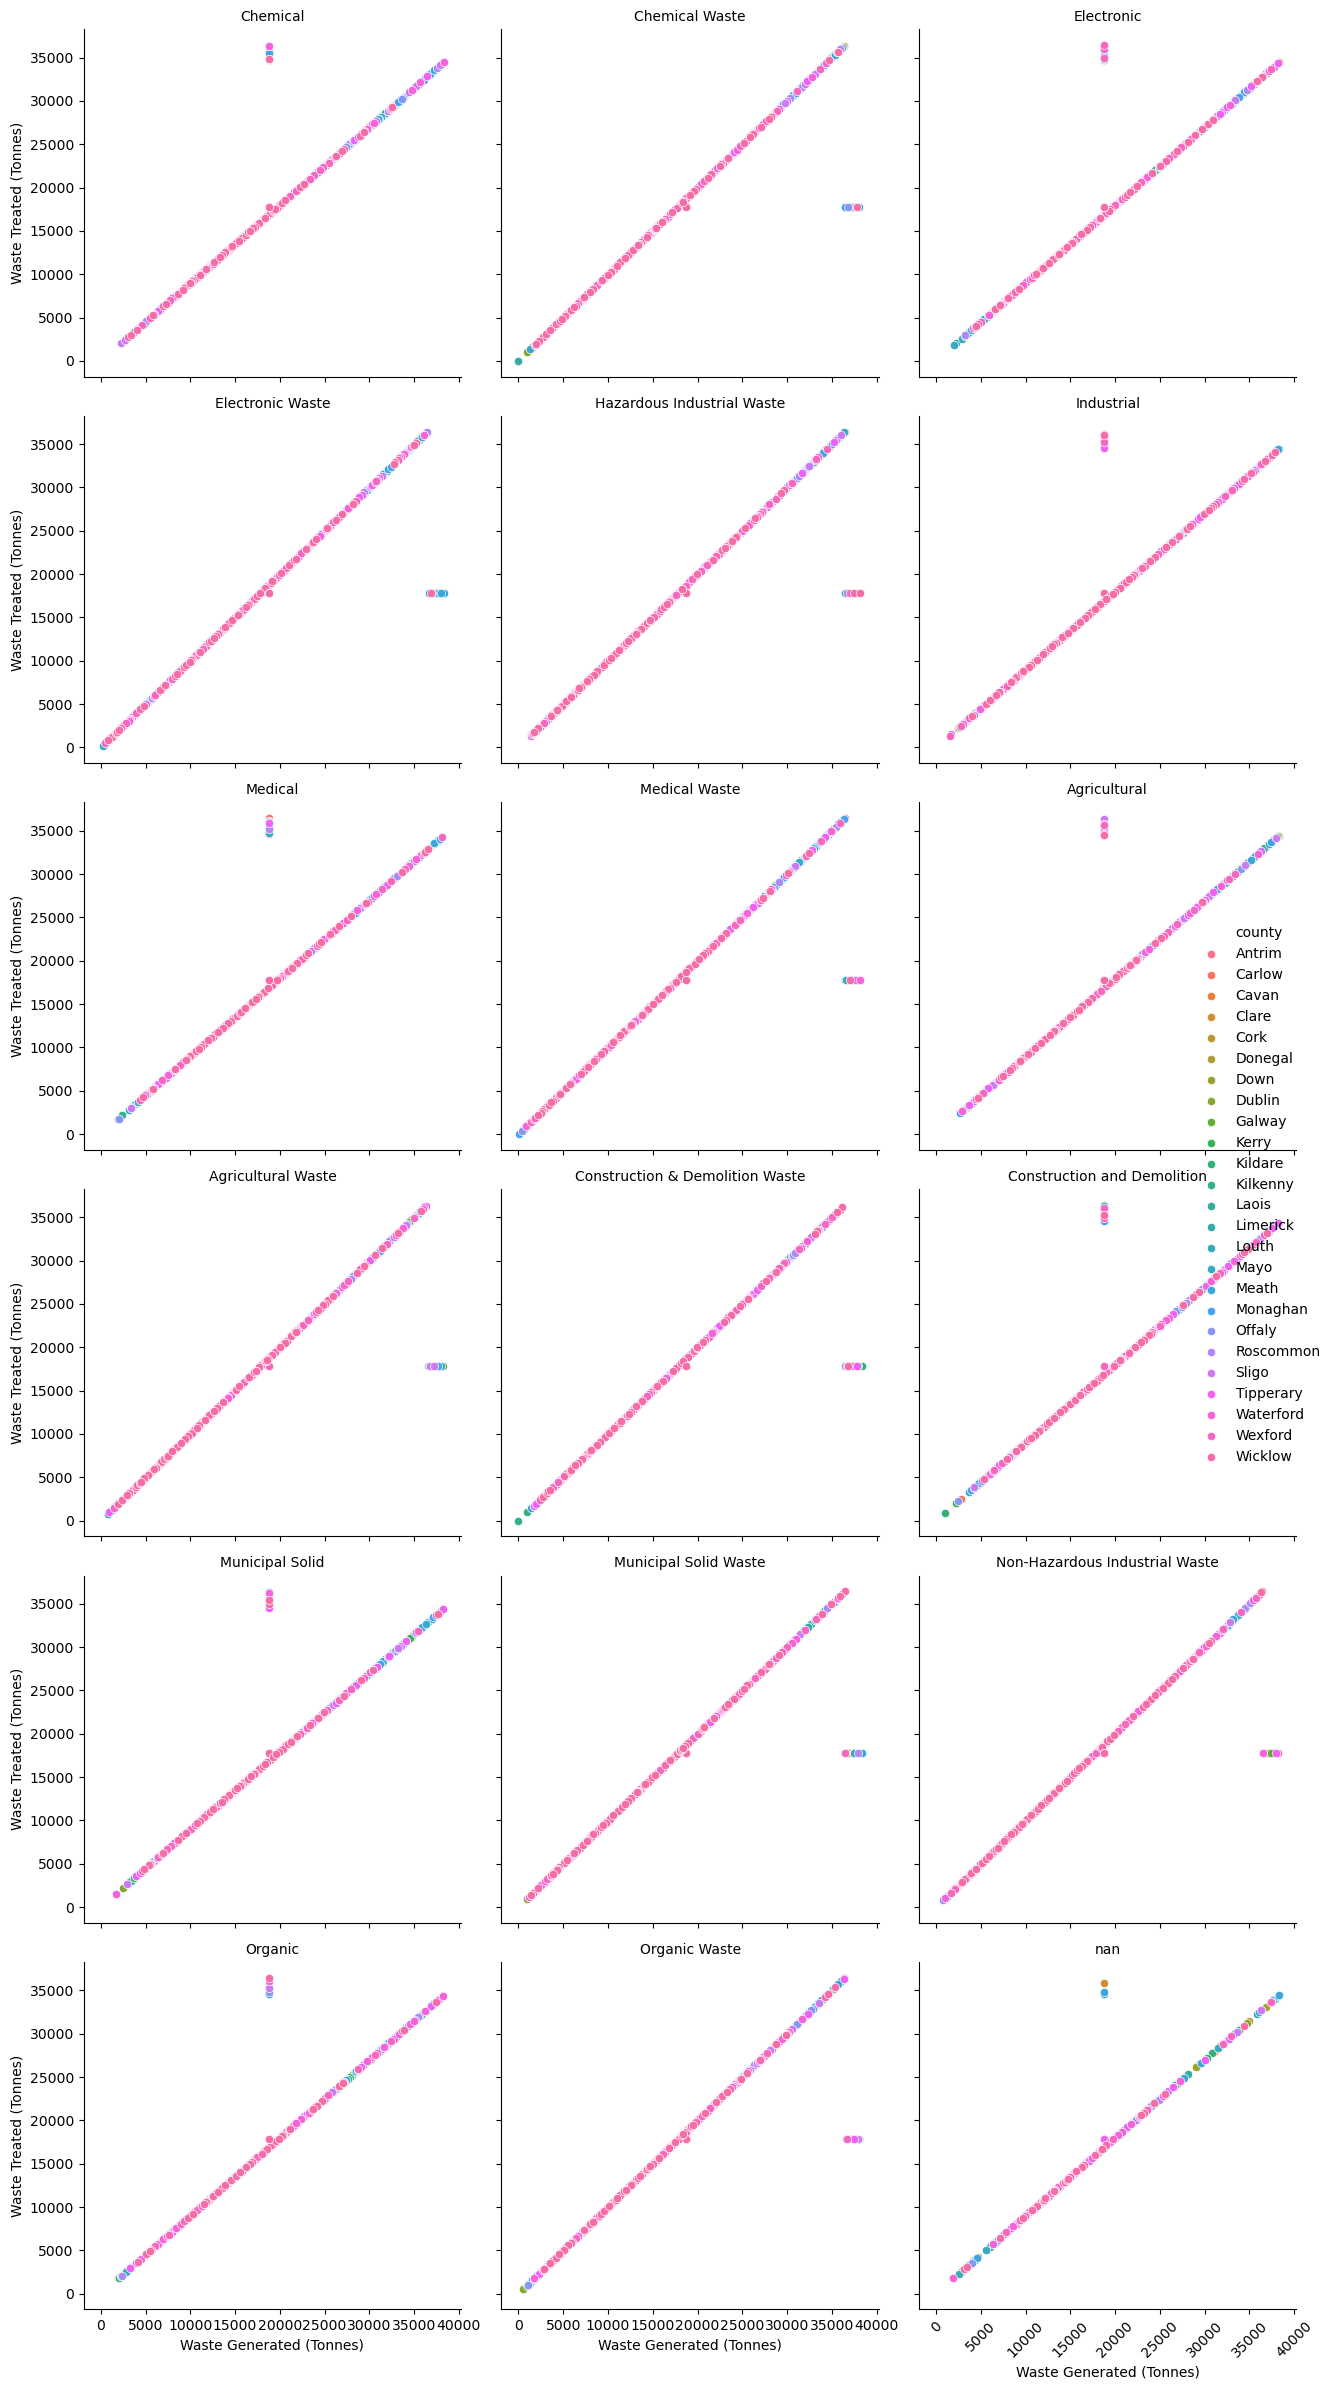

In [ ]:
# FacetGrid to visualize the relationship between numerical columns by categorical groupings
g = sns.FacetGrid(merged_df, col="waste_category", hue="county", col_wrap=3, height=4, aspect=1)
g.map(sns.scatterplot, "waste_generated_(tonnes)", "waste_treated_(tonnes)")

# Add legend and adjust layout
g.add_legend()
g.set_axis_labels("Waste Generated (Tonnes)", "Waste Treated (Tonnes)")
g.set_titles("{col_name}")  # Display category name as title for each facet
plt.xticks(rotation=45)  # Optional: Rotate x-axis labels for readability

# Show plot
plt.tight_layout()
plt.show()


**This graph compares waste generation trends across various types of waste (chemical, electronic, medical, agricultural, industrial, construction & municipal solid waste) among different Irish counties. This means that there a very well-defined linear correlation for 13 states in waste generation and treatment (as seen in the scatter plots, bottom right), which suggests that the waste management systems across categories are working efficiently. Points perint on plastic, paper and metal, organic and residual waste are colored by county; it can also be observed how in the majority of counties the same "tendencies" can be seen in the generation and treatment of the waste, which suggests compliance on management of waste across Ireland.**

**From these plots, we can see that the majority of the types of waste follow a relatively linear progression upwards with waste treated closely following amounts of waste generated. This is especially prominent in sectors such as municipal solid waste, construction & demolition waste, and industrial waste, where robust linear correlations exist. The existence of outlier points of some categories of waste (e.g., electronic waste and medical waste) indicates that in some instances deviations from the norm may occur.**

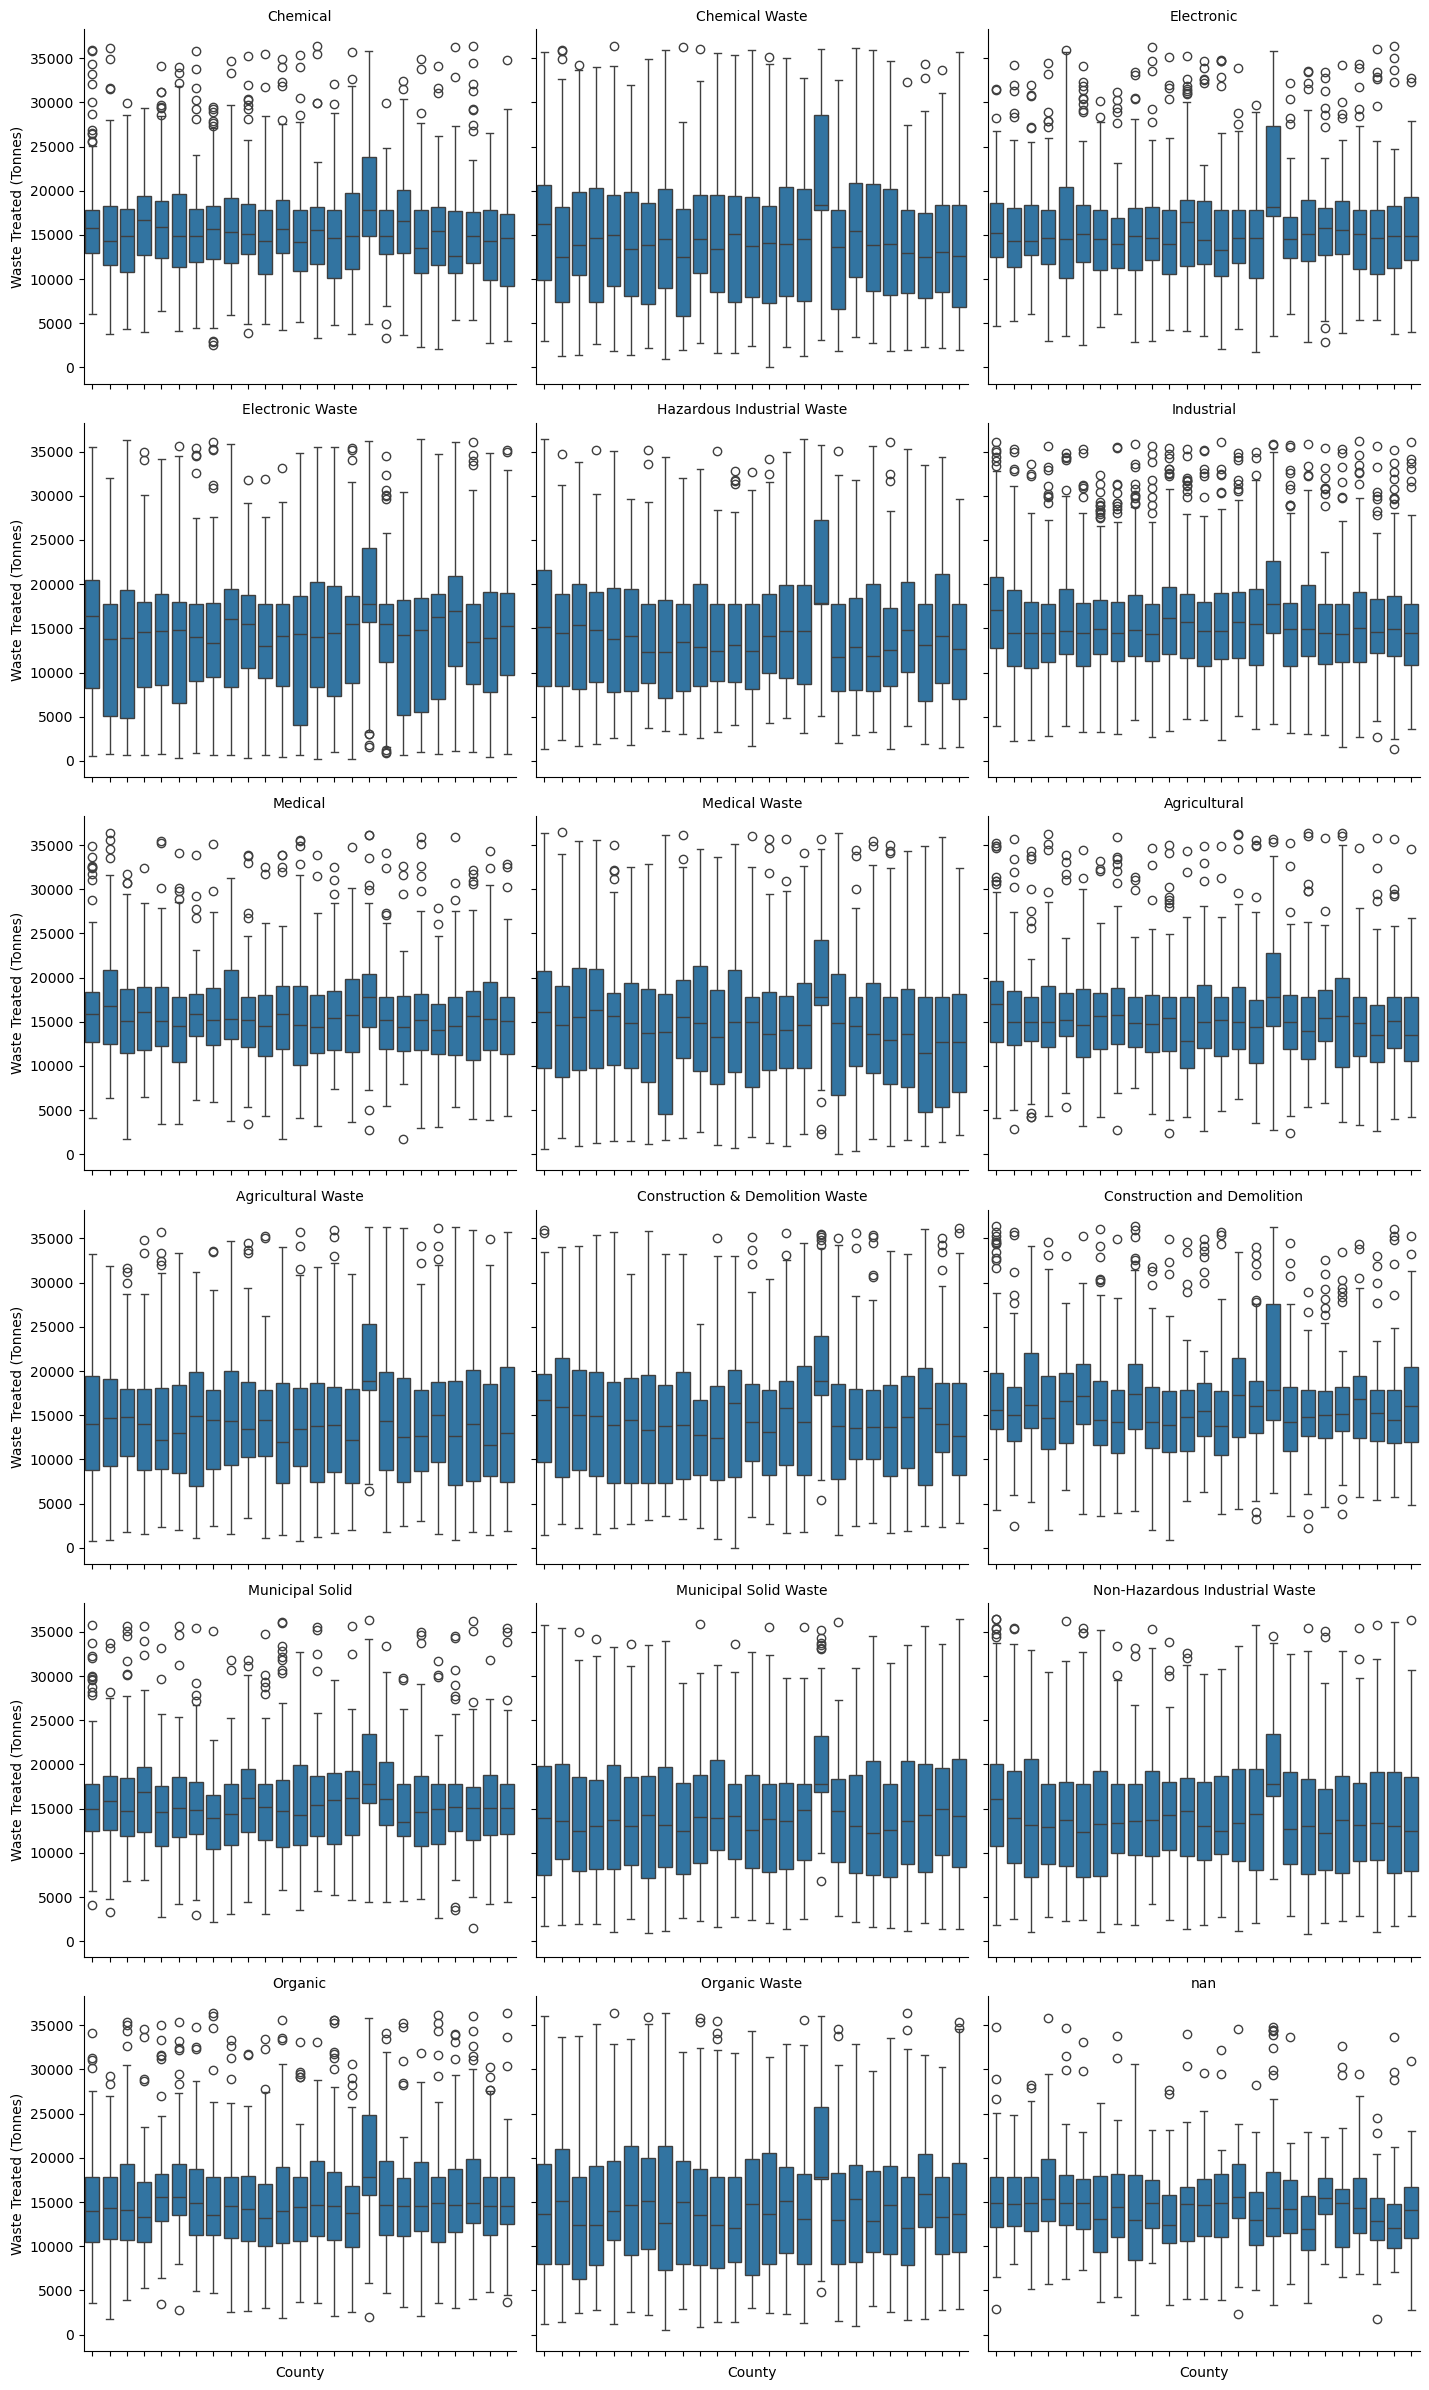

In [ ]:
# FacetGrid with boxplot to show distribution
g = sns.FacetGrid(merged_df, col="waste_category", col_wrap=3, height=4, aspect=1.2)
g.map(sns.boxplot, "county", "waste_treated_(tonnes)", order=merged_df["county"].unique())

# Set titles and labels
g.set_axis_labels("County", "Waste Treated (Tonnes)")
g.set_titles("{col_name}")  # Display waste_category in each facet title
g.set_xticklabels(rotation=45)  # Rotate x-axis labels for better readability

# Adjust layout
plt.tight_layout()
plt.show()


**This dashboard visualizes the waste treatment in a total of 16 box plots across the counties based on separates for waste types of chemical, electronics, medical, agriculture, construction, and municipal solid waste. The y-axis at the left is for waste treated (in thousand tons), while median levels of most categories are found to be within the 10,000 to 20,000 thousand tons range, however, the several outlier points above the boxes indicates the some counties required more than 20,000 thousand tons of irrigation. The consistent pattern across all waste types provides evidence of some standardisation in waste management systems, however, the presence of outliers suggests that some counties accept significantly larger volumes of waste – potentially as regional treatment centres or through greater volumes of industry.**

In [ ]:
# Relationship between county and waste treated

fig, ax = plt.subplots(figsize = (10, 7))
sns.countplot(x = "county", hue = "waste_treated_(tonnes)", data = merged_df)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize = (10, 7))
sns.countplot(x = "county", hue = "price_of_treatment_(€_per_tonne)", data = merged_df)
plt.show()

In [ ]:

# Example visualization with annotations
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Variable1', y='Variable2', data=df, hue='Category')
plt.title('Scatterplot of Variable1 vs Variable2 by Category')
plt.xlabel('Variable1')
plt.ylabel('Variable2')
plt.annotate('Key observation here', xy=(x, y), xytext=(x_offset, y_offset),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.show()



# Conclusions

 With two datasets,we were able to deduce significant waste management practices county-wise as well as quarter-wise. This analysis found large variation in treatment by waste type, for example, for hazardous and electronic waste recycling was often cheaper than incineration. And regional patterns became apparent, with counties like Antrim localising their priorities for treating hazardous waste, such as by incineration. Seasonal trends in waste generation were also identified, possibly reflecting cycles of industrial or residential activity. Nonetheless, the analytical process faced multiple hardships. Issues included inconsistent formats in the Quarter and County columns which required heavy preprocessing. Key fields, including Waste Amount (tonnes) and County, contained missing data, narrowing the focus of the analysis. And, having been stored as text, numerical fields such as Waste Amount (tonnes) and Price of Treatment (€ per tonne) required conversion to a different format for effective analysis.

In respect to the low cost and high energy saving of the environmental benefits of recycling, resources should be devoted to perfecting recycling methods, especially when it comes to recycling electronic and hazardous waste. Also, it may help in optimizing waste collection and treatment capacity by utilizing seasonal trends in waste generation. Predictive models for future waste generation and treatment costs can be developed from historical data and external factors. Data on socio-economic and environmental aspects should be integrated to better understand the reasons behind the generation of waste and the treatment of waste.


